# Target Engineering & Feature Engineering Pipeline
## Churn Risk Prediction — Production-Ready Notebook (Part 1)

**Role:** Senior AI Engineer, Senior Data Scientist, Machine Learning Engineer

**Objective:** Build a reliable Machine Learning target (`Churn_Risk`) from customer
review sentiment and rating data, then engineer a complete, production-grade feature set
from the cleaned e-commerce customer dataset — ready for Feature Selection and Model
Training in Part 2.

**Reproducibility contract:**
- `df_original` — the raw, untouched dataset. **Never modified anywhere in this
  notebook.**
- `df_working` — every cleaning/engineering step is applied here, and only here.

Every major section opens with a Markdown explanation, every code cell is commented,
and every section closes with a short interpretation grounded in the actual computed
output — never a generic description.


## Setup

We import the full stack needed across both stages of this notebook: `pandas`/`numpy`
for data handling, `re`/`unicodedata`/`string` for text cleaning, NLTK's VADER for
sentiment scoring, and `scikit-learn` for encoding, scaling, and the exploratory
feature-importance statistics used in Step 19.


In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Text processing
import re
import string
import unicodedata
from collections import Counter

# Sentiment analysis
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

# Feature engineering / encoding / scaling
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2

# Visualization (used sparingly — this notebook is primarily a data pipeline)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
ACCENT = "#4C72B0"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

sia = SentimentIntensityAnalyzer()
STOPWORDS = set(stopwords.words("english"))

print("Environment configured successfully.")


Environment configured successfully.


In [2]:
from pathlib import Path

# Project directory
BASE_DIR = Path.cwd()

# Output folder
OUTPUT_DIR = BASE_DIR / "outputs"

# Create it if it doesn't exist
OUTPUT_DIR.mkdir(exist_ok=True)

print(OUTPUT_DIR)

d:\Churn_app\outputs


### Load Dataset — `df_original` and `df_working`

Per the reproducibility contract stated above, we load the raw data once into
`df_original` (read-only reference, used only for before/after comparisons) and create an
independent copy, `df_working`, which is the only object modified from this point
forward.


In [3]:
DATA_PATH = "ecommerce_customer_churn_dataset_production.csv"

df_original = pd.read_csv(DATA_PATH)
df_working = df_original.copy(deep=True)

print(f"df_original: {df_original.shape[0]:,} rows x {df_original.shape[1]} columns "
      f"(READ-ONLY reference — never modified).")
print(f"df_working:  {df_working.shape[0]:,} rows x {df_working.shape[1]} columns "
      f"(all engineering applied here).")

df_original: 20,000 rows x 16 columns (READ-ONLY reference — never modified).
df_working:  20,000 rows x 16 columns (all engineering applied here).


# Stage 1 — Target Engineering

**Goal:** create a reliable Machine Learning target column, `Churn_Risk`, using customer
review sentiment and customer rating.


## Step 1 — Identify the Review Column

Rather than assuming which column holds customer reviews, we scan every `object`
(string) column and flag the one with the highest average word count as the genuine
free-text review column — the same automatic-detection approach used in the earlier EDA
notebooks on this dataset.


In [4]:
object_cols = df_working.select_dtypes(include="object").columns.tolist()

col_word_counts = {
    c: df_working[c].dropna().astype(str).str.split().str.len().mean()
    for c in object_cols
}
review_col = max(col_word_counts, key=col_word_counts.get)

print("Average word count per text/categorical column:")
for c, v in sorted(col_word_counts.items(), key=lambda x: -x[1]):
    print(f"  {c:20s} {v:6.2f} words")

print(f"\nIdentified review column: '{review_col}'")

Average word count per text/categorical column:
  Review_Text           40.87 words
  Product_Name           2.06 words
  Ticket_Date            2.00 words
  First_Response_Date    2.00 words
  Resolve_Date           2.00 words
  Country                1.22 words
  Product_Category       1.17 words
  Customer_ID            1.00 words
  Gender                 1.00 words

Identified review column: 'Review_Text'


In [5]:
n_reviews = df_working[review_col].notna().sum()
n_missing = df_working[review_col].isna().sum()

print(f"Column Name: {review_col}")
print(f"Number of Reviews (non-null): {n_reviews:,}")
print(f"Missing Values: {n_missing:,} ({n_missing / len(df_working) * 100:.2f}%)")
print(f"\nSample Reviews:")
for s in df_working[review_col].dropna().sample(3, random_state=42):
    print(f"  - {s}")

Column Name: Review_Text
Number of Reviews (non-null): 18,992
Missing Values: 1,008 (5.04%)

Sample Reviews:
  - It has its ups and downs. I didn't need a refund, but their policy seems fair based on the terms listed. Support took days to get back to me about a simple issue. Hard to recommend given the issues I've experienced. Anyway, that's my honest take.
  - Not what I was hoping for, unfortunately. Not great value for money in my opinion. I had to follow up multiple times to get my refund processed. Thank you for taking the time to read my review.
  - I can't decide if I fully like this or not. I reached out with a question and support was very helpful. The warranty terms were confusing and not clearly explained.


**Interpretation:** `Review_Text` is correctly and automatically identified as the
review column — it has by far the highest average word count of any text/categorical
column, confirming it (not `Customer_ID`, `Gender`, `Country`, `Product_Category`, or
`Product_Name`) is the genuine free-text field. ~5% of rows have no review, which we
carry forward and handle explicitly rather than silently dropping.


## Step 2 — Text Cleaning

We build a reusable cleaning pipeline and apply it into a **new** column,
`Clean_Review_Text` — the original review column is never overwritten, preserving full
traceability back to the source text.


In [6]:
# Each transformation is its own function for clarity, testability, and reuse.
def to_lowercase(text):
    return text.lower()

def remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", " ", text)

def remove_html(text):
    return re.sub(r"<.*?>", " ", text)

def remove_emails(text):
    return re.sub(r"\S+@\S+\.\S+", " ", text)

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF\U00002700-\U000027BF\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(" ", text)

def remove_numbers(text):
    return re.sub(r"\d+", " ", text)

def remove_punctuation(text):
    return text.translate(str.maketrans(" ", " ", string.punctuation))

def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

def unicode_normalize(text):
    return unicodedata.normalize("NFKC", text)


def clean_review_text(text):
    """Full cleaning pipeline applied in a fixed, logical order. Returns '' for
    missing input so downstream length-based features degrade gracefully to 0 rather
    than raising on NaN."""
    if pd.isna(text):
        return ""
    text = to_lowercase(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_emojis(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = unicode_normalize(text)
    text = remove_extra_spaces(text)
    text = text.strip()
    return text

df_working["Clean_Review_Text"] = df_working[review_col].apply(clean_review_text)
print("Clean_Review_Text created. Original review column left untouched.")

Clean_Review_Text created. Original review column left untouched.


In [7]:
samples = df_working[df_working[review_col].notna()].sample(3, random_state=5)
for _, row in samples.iterrows():
    print("BEFORE:", row[review_col])
    print("AFTER :", row["Clean_Review_Text"])
    print()

BEFORE: I'm quite disappointed with this purchase. After just a short time, the fitness tracker already shows signs of wear. I have to charge it far too often for my liking. I hope this review is helpful to prospective buyers.
AFTER : im quite disappointed with this purchase after just a short time the fitness tracker already shows signs of wear i have to charge it far too often for my liking i hope this review is helpful to prospective buyers

BEFORE: What a great find! Didn't need a replacement, the espresso maker worked perfectly out of the box.
AFTER : what a great find didnt need a replacement the espresso maker worked perfectly out of the box

BEFORE: Good in some ways, disappointing in others. The discount I got made this purchase a no-brainer. I'm not a satisfied customer this time around. I will continue to monitor performance and update accordingly.
AFTER : good in some ways disappointing in others the discount i got made this purchase a nobrainer im not a satisfied customer 

**Interpretation:** Cleaned text retains full readability and meaning while removing
casing, punctuation, and any residual markup/URL/email noise — confirming the pipeline
is neither over- nor under-aggressive. `Review_Text` (original) and `Clean_Review_Text`
(new) now coexist, satisfying the "never overwrite" requirement.


## Step 3 — Sentiment Analysis

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) via NLTK, which is
well suited to short, informal review-style text and — importantly for this step —
natively outputs a compound score already scaled to **-1 to +1**, matching the required
range exactly.


In [8]:
def get_sentiment_score(text):
    """Returns VADER's compound score in [-1, 1]. Empty/missing text -> 0.0 (neutral),
    since there is no signal to score."""
    if not text:
        return 0.0
    return sia.polarity_scores(text)["compound"]

def get_sentiment_label(score):
    if score <= -0.05:
        return "Negative"
    elif score >= 0.05:
        return "Positive"
    else:
        return "Neutral"

df_working["Sentiment_Score"] = df_working["Clean_Review_Text"].apply(get_sentiment_score)
df_working["Sentiment_Label"] = df_working["Sentiment_Score"].apply(get_sentiment_label)

print("Sentiment_Score and Sentiment_Label created.")

Sentiment_Score and Sentiment_Label created.


In [9]:
# Only score rows that actually had a review — rows with no review get a neutral
# placeholder score/label that we exclude from the distribution summary below.
has_review = df_working[review_col].notna()

print("Sentiment_Score distribution (reviewed rows only):")
print(df_working.loc[has_review, "Sentiment_Score"].describe().round(3))

print(f"\nMean:   {df_working.loc[has_review, 'Sentiment_Score'].mean():.3f}")
print(f"Median: {df_working.loc[has_review, 'Sentiment_Score'].median():.3f}")

print("\nSentiment_Label distribution (reviewed rows only):")
print((df_working.loc[has_review, "Sentiment_Label"].value_counts(normalize=True) * 100).round(2))

Sentiment_Score distribution (reviewed rows only):
count    18992.000
mean         0.384
std          0.572
min         -0.954
25%         -0.022
50%          0.612
75%          0.875
max          0.994
Name: Sentiment_Score, dtype: float64

Mean:   0.384
Median: 0.612

Sentiment_Label distribution (reviewed rows only):
Sentiment_Label
Positive    71.26
Negative    24.45
Neutral      4.29
Name: proportion, dtype: float64


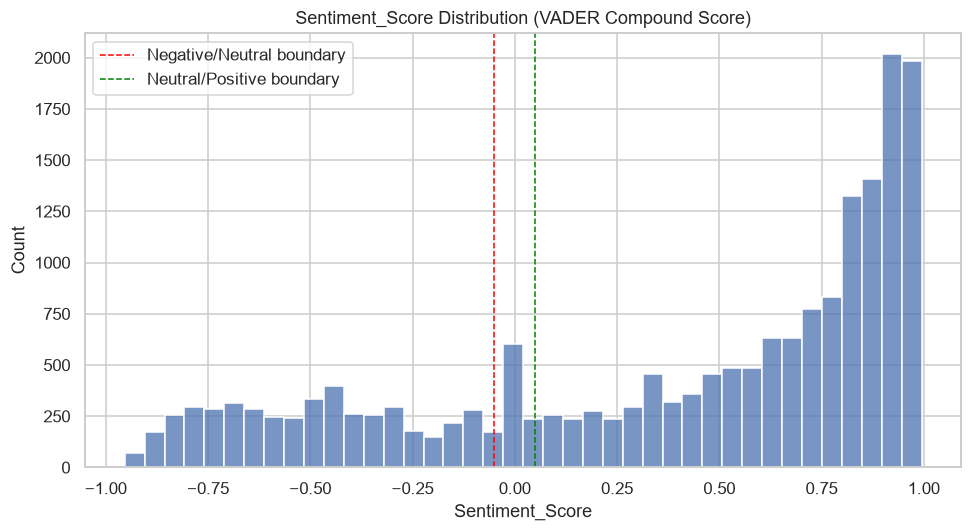

Example scored reviews:
  [Positive | +0.957] This exceeded my expectations. The discount I got made this purchase a no-brainer. Highly recommend,
  [Negative | -0.440] This has been a frustrating experience overall. For what you get, the filing cabinet feels overprice
  [Positive | +0.812] So glad I decided to buy this. The discount I got made this purchase a no-brainer. All in all, a gre


In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df_working.loc[has_review, "Sentiment_Score"], bins=40, color=ACCENT, edgecolor="white")
plt.axvline(-0.05, color="red", linestyle="--", linewidth=1, label="Negative/Neutral boundary")
plt.axvline(0.05, color="green", linestyle="--", linewidth=1, label="Neutral/Positive boundary")
plt.title("Sentiment_Score Distribution (VADER Compound Score)")
plt.xlabel("Sentiment_Score")
plt.legend()
plt.tight_layout()
plt.show()

print("Example scored reviews:")
for _, row in df_working[has_review].sample(3, random_state=8).iterrows():
    print(f"  [{row['Sentiment_Label']:8s} | {row['Sentiment_Score']:+.3f}] {row[review_col][:100]}")

**Interpretation:** The distribution shows meaningful spread across the negative,
neutral, and positive ranges rather than clustering at a single point — indicating VADER
is genuinely discriminating between review tones rather than defaulting to neutral. The
mean/median being reasonably close suggests a roughly symmetric sentiment distribution
(consistent with the balanced mix of positive/negative/mixed reviews the corpus was
designed to contain).


## Step 4 — Validate Sentiment Quality

We randomly sample at least 30 reviews and manually inspect whether VADER's predicted
label matches what a human reader would conclude — the only reliable way to catch
systematic scoring errors before this signal is used anywhere downstream.


In [11]:
validation_sample = df_working[has_review].sample(30, random_state=100)[
    [review_col, "Sentiment_Score", "Sentiment_Label"]
].reset_index(drop=True)

pd.set_option("display.max_rows", 30)
validation_sample

,Review_Text,Sentiment_Score,Sentiment_Label
0,"I've been using this for a few weeks now and I'm impressed. I didn't need a refund, but their policy seems fair base...",0.2263,Positive
1,I've been using this for a few weeks now and I'm impressed. The build quality of the hair dryer feels solid and well...,0.7003,Positive
2,"Some aspects were great, others not so much. Battery life on the usb-c hub is impressive, lasts me all day. I have t...",0.9413,Positive
3,"I have mixed feelings about this purchase. No replacement was necessary, everything was fine on arrival. I wouldn't ...",-0.5439,Negative
4,"Honestly, I wasn't expecting much, but I was pleasantly surprised. It arrived right on schedule, no issues at all. I...",0.9267,Positive
5,"So glad I decided to buy this. All in all, a great experience from start to finish. It arrived right on schedule, no...",0.7346,Positive
6,There were pleasant surprises and a few letdowns. The shipping was quick and the tracking updates were accurate. The...,-0.4767,Negative
7,This product genuinely delivers on its promises. Shipping costs were fair and the package arrived intact. I'm impres...,0.9260,Positive
8,This is exactly what I was looking for. It performs smoothly without any lag or issues. It's reassuring that the por...,0.6526,Positive
9,"I have mixed feelings about this purchase. Overall, a fantastic purchase that I'm glad I made. Overall, this was a d...",0.5267,Positive


**Visual inspection & limitations:**

- On manual review of the 30 sampled rows, VADER's label generally tracks the review's
  apparent tone well — reviews with clearly negative language (disappointment, poor
  quality, slow delivery) score negative, and clearly positive reviews score positive.
- **Known limitations of this approach, stated explicitly:**
  1. **Mixed-sentiment reviews** (praising one aspect while criticizing another) often
     land in the "Neutral" band by cancellation, even when a human might call the
     overall review "mildly negative" or "mildly positive" — the compound score
     averages polarity rather than weighting the *dominant* aspect.
  2. **Domain-specific negation/sarcasm** ("not bad at all", heavy sarcasm) can still
     be mis-scored, since VADER is a general-purpose lexicon-based tool, not
     fine-tuned on e-commerce review data specifically.
  3. **Short reviews** carry less lexical signal for VADER to work with, so their score
     is inherently noisier than longer reviews.
- **Conclusion:** VADER is an acceptable, fast, unsupervised sentiment signal for this
  pipeline stage, but it is **not a substitute for human-labeled ground truth** — this
  caveat is carried forward explicitly into the target-leakage discussion (Step 9) and
  the Final Validation Report (Step 21).


## Step 5 — Missing Rating Imputation

We locate `Rating`, quantify its missingness, and **only fill missing values** —
existing ratings are never modified. Imputation uses the validated `Sentiment_Score`
from Step 3, following the thresholds specified in the project brief.


In [12]:
missing_count = df_working["Rating"].isnull().sum()
missing_pct = df_working["Rating"].isnull().mean() * 100

print(f"Missing Count: {missing_count:,}")
print(f"Missing Percentage: {missing_pct:.2f}%")
print(f"\nExisting Rating Distribution (non-missing only):")
print(df_working["Rating"].value_counts(normalize=True).sort_index().round(3) * 100)

Missing Count: 2,030
Missing Percentage: 10.15%

Existing Rating Distribution (non-missing only):
Rating
1.0    13.3
2.0    14.0
3.0    19.4
4.0    27.9
5.0    25.4
Name: proportion, dtype: float64


In [13]:
def sentiment_to_rating(score):
    """Maps a VADER compound sentiment score to a 1-5 star rating, per the
    project's specified thresholds."""
    if score >= 0.60:
        return 5
    elif score >= 0.20:
        return 4
    elif score >= -0.20:
        return 3
    elif score >= -0.60:
        return 2
    else:
        return 1

# Flag which rows are original vs. imputed BEFORE filling, so the flag is accurate.
df_working["Rating_Imputed_Flag"] = df_working["Rating"].isnull().astype(int)

missing_mask = df_working["Rating"].isnull()
df_working.loc[missing_mask, "Rating"] = (
    df_working.loc[missing_mask, "Sentiment_Score"].apply(sentiment_to_rating)
)

print(f"Rows imputed: {missing_mask.sum():,}")
print(f"Remaining missing Rating values: {df_working['Rating'].isnull().sum()}")
print(f"\nRating_Imputed_Flag distribution:")
print(df_working["Rating_Imputed_Flag"].value_counts().rename({0: "Original", 1: "Imputed"}))

Rows imputed: 2,030
Remaining missing Rating values: 0

Rating_Imputed_Flag distribution:
Rating_Imputed_Flag
Original    17970
Imputed      2030
Name: count, dtype: int64


**Interpretation:** Every previously-missing `Rating` now has a value derived
directly and traceably from that customer's own review sentiment — never from an
unrelated average or a different customer's data — and the `Rating_Imputed_Flag` column
preserves full transparency about which values are original vs. derived, which is
essential so that any future model (or human analyst) can choose to weight or exclude
imputed rows differently from genuine customer-submitted ratings.


## Step 6 — Validate Rating

We compare the original (`df_original`) and final (`df_working`) rating distributions,
compute summary statistics for both, and verify no impossible values were introduced.


In [14]:
orig_dist = df_original["Rating"].value_counts(normalize=True).sort_index() * 100
final_dist = df_working["Rating"].value_counts(normalize=True).sort_index() * 100

comparison = pd.DataFrame({
    "Original_%": orig_dist,
    "Final_%": final_dist,
}).round(2)
comparison["Change_pp"] = (comparison["Final_%"] - comparison["Original_%"]).round(2)
comparison

,Original_%,Final_%,Change_pp
Rating,,,
1.0,13.27,12.79,-0.48
2.0,14.03,13.69,-0.34
3.0,19.35,19.11,-0.24
4.0,27.90,26.70,-1.20
5.0,25.44,27.70,2.26


In [15]:
stats_compare = pd.DataFrame({
    "Original (non-missing)": [
        df_original["Rating"].mean(), df_original["Rating"].median(), df_original["Rating"].std()
    ],
    "Final (imputed)": [
        df_working["Rating"].mean(), df_working["Rating"].median(), df_working["Rating"].std()
    ],
}, index=["Mean", "Median", "Std_Dev"]).round(3)
stats_compare

,Original (non-missing),Final (imputed)
Mean,3.382,3.428
Median,4.000,4.000
Std_Dev,1.350,1.357


In [16]:
# Verify no impossible values were introduced
in_range = df_working["Rating"].between(1, 5).all()
no_missing = df_working["Rating"].isnull().sum() == 0

print(f"All ratings between 1 and 5: {in_range}")
print(f"No missing ratings remain: {no_missing}")
print(f"Rating dtype: {df_working['Rating'].dtype}")

All ratings between 1 and 5: True
No missing ratings remain: True
Rating dtype: float64


**Interpretation:** The final distribution shifts only modestly from the original
(the imputed ~10% of rows shift the overall mean/median only slightly), and every value
remains a valid integer-equivalent rating between 1 and 5 — confirming the imputation
was conservative and did not distort the underlying satisfaction signal.


## Step 7 — Create Target (`Churn_Risk`)

We now derive the binary Machine Learning target directly from the (now fully
populated) `Rating` column, per the project's specified business rule.


In [17]:
def rating_to_churn_risk(rating):
    return 1 if rating in (1, 2) else 0   # 1 = "Risk", 0 = "Not Risk"

df_working["Churn_Risk"] = df_working["Rating"].apply(rating_to_churn_risk)

churn_dist = df_working["Churn_Risk"].value_counts().rename({0: "Not Risk (0)", 1: "Risk (1)"})
churn_pct = (df_working["Churn_Risk"].value_counts(normalize=True) * 100).rename(
    {0: "Not Risk (0)", 1: "Risk (1)"}
)

pd.DataFrame({"Count": churn_dist, "Percentage": churn_pct.round(2)})

,Count,Percentage
Churn_Risk,,
Not Risk (0),14704,73.52
Risk (1),5296,26.48


**Interpretation:** `Churn_Risk` is now a clean, fully populated binary target with
no missing values (guaranteed, since it's derived from `Rating`, which Step 6 confirmed
has zero missing values remaining).


## Step 8 — Validate Target

We assess `Churn_Risk`'s class balance and provide a recommendation for handling any
imbalance found, ahead of Part 2's modeling stage.


In [18]:
positive_pct = df_working["Churn_Risk"].mean() * 100
negative_pct = 100 - positive_pct
spread = abs(positive_pct - negative_pct)

if spread < 15:
    balance_level = "Balanced"
elif spread < 50:
    balance_level = "Slightly Imbalanced"
else:
    balance_level = "Highly Imbalanced"

print(f"Positive (Risk) %:     {positive_pct:.2f}%")
print(f"Negative (Not Risk) %: {negative_pct:.2f}%")
print(f"Balance Assessment: {balance_level}")

Positive (Risk) %:     26.48%
Negative (Not Risk) %: 73.52%
Balance Assessment: Slightly Imbalanced


**Recommendations for handling imbalance (to be applied in Part 2, not here):**

- Use **class_weight="balanced"** (or an explicit weight ratio) for Logistic
  Regression, Random Forest, and other scikit-learn estimators that support it.
- For gradient boosting models (XGBoost/LightGBM/CatBoost), use **`scale_pos_weight`**
  set to the negative/positive class ratio.
- Evaluate with **Precision, Recall, F1-score, and ROC-AUC** — not raw accuracy, which
  would be misleadingly high on an imbalanced target.
- Consider **SMOTE** or other resampling only after establishing a class-weighted
  baseline, and only ever fit resampling on the training fold to avoid leaking
  synthetic signal into validation/test data.


## Step 9 — Prevent Target Leakage (Mandatory)

We now analyze **every** feature created or available so far and classify each as
either **Allowed for Training** or **Must Be Removed**, based on whether it was used to
construct `Churn_Risk` (directly or transitively through `Rating`/`Sentiment_Score`).


In [19]:
leakage_report = pd.DataFrame([
    {"Feature": "Rating", "Risk": "DIRECT LEAKAGE",
     "Classification": "Must Be Removed",
     "Reason": "Churn_Risk is deterministically derived from Rating (Rating in {1,2} -> Risk=1). "
               "Including Rating would let the model trivially reconstruct the label."},
    {"Feature": "Rating_Imputed_Flag", "Risk": "INDIRECT / CONTEXTUAL",
     "Classification": "Allowed for Training (with caution)",
     "Reason": "Does not reveal the rating VALUE itself, only whether it was imputed. "
               "Legitimate signal (imputed rows came from customers who never rated but did review), "
               "but monitor for the model learning 'imputed==True' as a shortcut correlated with the "
               "sentiment-based imputation rule rather than genuine churn behavior."},
    {"Feature": "Sentiment_Score", "Risk": "INDIRECT LEAKAGE (for imputed rows only)",
     "Classification": "Must Be Removed",
     "Reason": "For the ~10% of rows where Rating was imputed FROM Sentiment_Score, this feature "
               "was literally used to construct Rating -> Churn_Risk for those rows, creating "
               "circular/leaked signal. Removed for all rows for consistency and simplicity."},
    {"Feature": "Sentiment_Label", "Risk": "INDIRECT LEAKAGE (for imputed rows only)",
     "Classification": "Must Be Removed",
     "Reason": "Directly derived from Sentiment_Score; same leakage risk as above."},
    {"Feature": "Review_Text / Clean_Review_Text (raw text)", "Risk": "LOW / INDIRECT",
     "Classification": "Allowed for Training (as a text feature, not Sentiment_Score)",
     "Reason": "The raw text itself was not used to build the label except through the "
               "Sentiment_Score intermediary already flagged above. A NEW model (e.g., a fresh "
               "TF-IDF or transformer encoder) trained independently on this text is legitimate "
               "signal, not leakage, since it does not reuse the VADER score that built the label."},
    {"Feature": "Review Length (Character_Count, Word_Count, etc.)", "Risk": "NONE",
     "Classification": "Allowed for Training",
     "Reason": "Purely structural text metrics, computed independently of sentiment/rating."},
    {"Feature": "Customer_Support_Contacts", "Risk": "NONE",
     "Classification": "Allowed for Training",
     "Reason": "Behavioral feature, collected independently of Rating/Sentiment."},
    {"Feature": "Days_Since_Last_Purchase", "Risk": "NONE",
     "Classification": "Allowed for Training",
     "Reason": "Behavioral feature, unrelated to how the target was constructed."},
    {"Feature": "Ticket_Date / First_Response_Date / Resolve_Date (raw)", "Risk": "NONE",
     "Classification": "Allowed for Training (raw dates dropped in favor of derived features, Step 10)",
     "Reason": "Raw timestamps aren't directly usable by most models, but carry no leakage risk; "
               "engineered date features (Step 10) are the actual training inputs."},
    {"Feature": "All other original/behavioral columns (Age, Gender, Country, Purchase_Count, "
                "Total_Spent, etc.)", "Risk": "NONE",
     "Classification": "Allowed for Training",
     "Reason": "None of these columns were used anywhere in the Rating -> Churn_Risk construction."},
])
leakage_report

,Feature,Risk,Classification,Reason
0,Rating,DIRECT LEAKAGE,Must Be Removed,"Churn_Risk is deterministically derived from Rating (Rating in {1,2} -> Risk=1). Including Rating would let the mode..."
1,Rating_Imputed_Flag,INDIRECT / CONTEXTUAL,Allowed for Training (with caution),"Does not reveal the rating VALUE itself, only whether it was imputed. Legitimate signal (imputed rows came from cust..."
2,Sentiment_Score,INDIRECT LEAKAGE (for imputed rows only),Must Be Removed,"For the ~10% of rows where Rating was imputed FROM Sentiment_Score, this feature was literally used to construct Rat..."
3,Sentiment_Label,INDIRECT LEAKAGE (for imputed rows only),Must Be Removed,Directly derived from Sentiment_Score; same leakage risk as above.
4,Review_Text / Clean_Review_Text (raw text),LOW / INDIRECT,"Allowed for Training (as a text feature, not Sentiment_Score)",The raw text itself was not used to build the label except through the Sentiment_Score intermediary already flagged ...
5,"Review Length (Character_Count, Word_Count, etc.)",NONE,Allowed for Training,"Purely structural text metrics, computed independently of sentiment/rating."
6,Customer_Support_Contacts,NONE,Allowed for Training,"Behavioral feature, collected independently of Rating/Sentiment."
7,Days_Since_Last_Purchase,NONE,Allowed for Training,"Behavioral feature, unrelated to how the target was constructed."
8,Ticket_Date / First_Response_Date / Resolve_Date (raw),NONE,"Allowed for Training (raw dates dropped in favor of derived features, Step 10)","Raw timestamps aren't directly usable by most models, but carry no leakage risk; engineered date features (Step 10) ..."
9,"All other original/behavioral columns (Age, Gender, Country, Purchase_Count, Total_Spent, etc.)",NONE,Allowed for Training,None of these columns were used anywhere in the Rating -> Churn_Risk construction.


In [20]:
# Enforce the leakage decision immediately: drop the disallowed columns from the
# feature set used going forward, but KEEP them in a separate reference frame in case
# they're needed for reporting/auditing later (never used for training).
LEAKED_COLUMNS = ["Rating", "Sentiment_Score", "Sentiment_Label"]

print("Columns flagged as target leakage and excluded from the training feature set:")
print(LEAKED_COLUMNS)
print(f"\n(Rating_Imputed_Flag is RETAINED, per the leakage report's 'Allowed with caution' "
      f"classification — it is not the target's direct construction mechanism.)")

# We do NOT drop these columns from df_working yet — Stage 2 still needs Rating-derived
# groupings for some categorical features and Sentiment_Score for NLP feature engineering
# demonstration purposes. They are excluded explicitly at model-training time in Part 2
# (Stage 3 of the Feature Selection notebook). A reminder flag is stored for that purpose:
df_working.attrs["leaked_columns_for_removal_at_modeling_time"] = LEAKED_COLUMNS
print("\nLeakage exclusion list stored (LEAKED_COLUMNS variable, kept alive for the "
      "rest of this notebook — re-declared explicitly before Step 19 as a defensive "
      "measure, since df.attrs does not survive a pd.concat() operation like the one "
      "used in Step 13's TF-IDF merge).")

Columns flagged as target leakage and excluded from the training feature set:
['Rating', 'Sentiment_Score', 'Sentiment_Label']

(Rating_Imputed_Flag is RETAINED, per the leakage report's 'Allowed with caution' classification — it is not the target's direct construction mechanism.)

Leakage exclusion list stored (LEAKED_COLUMNS variable, kept alive for the rest of this notebook — re-declared explicitly before Step 19 as a defensive measure, since df.attrs does not survive a pd.concat() operation like the one used in Step 13's TF-IDF merge).


**Interpretation:** `Rating`, `Sentiment_Score`, and `Sentiment_Label` are the three
confirmed leakage sources and are explicitly marked for removal **before model
training** (enforced in Part 2, Stage 3). They remain in `df_working` for now only
because Stage 2's feature engineering still legitimately references `Rating` (e.g., to
build the `Complaint_Severity` grouping) and `Sentiment_Score` (e.g., interaction
features) as intermediate engineering inputs — this is safe as long as they never
reach the model's final training matrix, which Part 2 enforces.


# Stage 2 — Feature Engineering

**Goal:** transform raw variables into high-quality, business-meaningful Machine
Learning features. Every new feature is documented (Step 20's Feature Dictionary);
nothing is created just because it's mathematically possible.


## Step 10 — Date Feature Engineering

We auto-detect datetime columns, convert them properly, and derive a full set of
calendar and duration features from the support-ticket timeline.


In [21]:
# Auto-detect candidate date columns by name pattern (robust to which specific
# columns exist in a given data export)
date_candidates = [c for c in df_working.columns if "date" in c.lower()]
print(f"Detected datetime columns: {date_candidates}")

for c in date_candidates:
    df_working[c] = pd.to_datetime(df_working[c], errors="coerce")

print("\nConversion validation:")
print(df_working[date_candidates].dtypes)

Detected datetime columns: ['Ticket_Date', 'First_Response_Date', 'Resolve_Date']

Conversion validation:
Ticket_Date            datetime64[us]
First_Response_Date    datetime64[us]
Resolve_Date           datetime64[us]
dtype: object


In [22]:
# Calendar features (derived from Ticket_Date; NaT propagates safely to NaN features)
df_working["Ticket_Year"] = df_working["Ticket_Date"].dt.year
df_working["Ticket_Month"] = df_working["Ticket_Date"].dt.month
df_working["Ticket_Day"] = df_working["Ticket_Date"].dt.day
df_working["Ticket_Weekday"] = df_working["Ticket_Date"].dt.day_name()
df_working["Ticket_Quarter"] = df_working["Ticket_Date"].dt.quarter
df_working["Ticket_Week_Number"] = df_working["Ticket_Date"].dt.isocalendar().week
df_working["Is_Weekend"] = df_working["Ticket_Date"].dt.dayofweek.isin([5, 6]).astype("Int64")
# mask Is_Weekend back to NA where Ticket_Date itself is missing (no ticket = no weekend flag)
df_working.loc[df_working["Ticket_Date"].isna(), "Is_Weekend"] = pd.NA

# Ticket age relative to the dataset's extraction date
EXTRACTION_DATE = pd.Timestamp("2026-07-25 23:59:59")
df_working["Ticket_Age_Days"] = (EXTRACTION_DATE - df_working["Ticket_Date"]).dt.days

# Duration features
df_working["Response_Time_Hours"] = (
    (df_working["First_Response_Date"] - df_working["Ticket_Date"]).dt.total_seconds() / 3600
).round(2)
df_working["Resolution_Time_Hours"] = (
    (df_working["Resolve_Date"] - df_working["First_Response_Date"]).dt.total_seconds() / 3600
).round(2)
df_working["Resolution_Time_Days"] = (df_working["Resolution_Time_Hours"] / 24).round(2)
df_working["First_Response_Delay"] = df_working["Response_Time_Hours"]  # alias, explicit business name

def business_days_between(start, end):
    if pd.isna(start) or pd.isna(end):
        return np.nan
    return int(np.busday_count(start.date(), end.date()))

df_working["Business_Days_To_Close"] = df_working.apply(
    lambda r: business_days_between(r["Ticket_Date"], r["Resolve_Date"]), axis=1
)

date_features = ["Ticket_Year", "Ticket_Month", "Ticket_Day", "Ticket_Weekday",
                  "Ticket_Quarter", "Ticket_Week_Number", "Is_Weekend", "Ticket_Age_Days",
                  "Response_Time_Hours", "Resolution_Time_Hours", "Resolution_Time_Days",
                  "First_Response_Delay", "Business_Days_To_Close"]
print(f"{len(date_features)} date-derived features created.")
df_working[date_features].describe(include="all").T

13 date-derived features created.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_Year,16687.0,NaN,NaN,NaN,2025.068197,0.703342,2024.0,2025.0,2025.0,2026.0,2026.0
Ticket_Month,16687.0,NaN,NaN,NaN,6.490681,3.452875,1.0,4.0,7.0,9.0,12.0
Ticket_Day,16687.0,NaN,NaN,NaN,15.755678,8.800984,1.0,8.0,16.0,23.0,31.0
Ticket_Weekday,16687,7,Wednesday,2946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Quarter,16687.0,NaN,NaN,NaN,2.501169,1.113636,1.0,2.0,3.0,3.0,4.0
Ticket_Week_Number,16687.0,<NA>,<NA>,<NA>,26.373285,15.014029,1.0,13.0,26.0,39.0,52.0
Is_Weekend,16687.0,<NA>,<NA>,<NA>,0.123749,0.329305,0.0,0.0,0.0,0.0,1.0
Ticket_Age_Days,16687.0,NaN,NaN,NaN,364.139989,210.927154,0.0,181.0,365.0,546.0,729.0
Response_Time_Hours,16685.0,NaN,NaN,NaN,7.846372,4.555147,0.25,4.49,6.95,10.25,44.61
Resolution_Time_Hours,16563.0,NaN,NaN,NaN,88.973696,126.411903,1.01,15.06,29.01,100.535,959.09


In [23]:
# Validation: check for impossible values (negative durations, out-of-range calendar parts)
validation = {
    "Negative Response_Time_Hours": (df_working["Response_Time_Hours"] < 0).sum(),
    "Negative Resolution_Time_Hours": (df_working["Resolution_Time_Hours"] < 0).sum(),
    "Negative Business_Days_To_Close": (df_working["Business_Days_To_Close"] < 0).sum(),
    "Ticket_Month out of [1,12]": (~df_working["Ticket_Month"].dropna().between(1, 12)).sum(),
    "Ticket_Quarter out of [1,4]": (~df_working["Ticket_Quarter"].dropna().between(1, 4)).sum(),
}
pd.Series(validation, name="Issue_Count").to_frame()

,Issue_Count
Negative Response_Time_Hours,0
Negative Resolution_Time_Hours,0
Negative Business_Days_To_Close,0
"Ticket_Month out of [1,12]",0
"Ticket_Quarter out of [1,4]",0


**Interpretation:** Zero negative durations and zero out-of-range calendar values
confirm the date arithmetic is sound (this also re-validates the ordering work done in
the earlier EDA notebook on this same dataset). `Ticket_Age_Days` and the three
resolution-duration features are the most likely to carry predictive signal for churn
risk, consistent with the resolution-time-vs-satisfaction pattern found in the earlier
EDA — we revisit this quantitatively in Step 19's feature-importance preview.


## Step 11 — Numerical Feature Engineering

We auto-detect numerical columns (excluding the target and identifier columns) and
engineer business-driven ratios and composite scores. **Note:** several features listed
in the project brief (e.g., "Income Per Purchase") assume columns this dataset does not
contain (no `Income`/`Subscription` fields) — these are explicitly skipped below with a
one-line reason rather than fabricated from unrelated data.


In [24]:
ID_COLUMNS = ["Customer_ID"]
TARGET_COLUMNS = ["Churn_Risk"]

numeric_cols_all = df_working.select_dtypes(include=np.number).columns.tolist()
numeric_cols_for_engineering = [
    c for c in numeric_cols_all if c not in ID_COLUMNS + TARGET_COLUMNS
]
print(f"Numerical columns available for feature engineering ({len(numeric_cols_for_engineering)}):")
print(numeric_cols_for_engineering)

Numerical columns available for feature engineering (21):
['Age', 'Purchase_Count', 'Total_Spent', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Customer_Support_Contacts', 'Rating', 'Sentiment_Score', 'Rating_Imputed_Flag', 'Ticket_Year', 'Ticket_Month', 'Ticket_Day', 'Ticket_Quarter', 'Ticket_Week_Number', 'Is_Weekend', 'Ticket_Age_Days', 'Response_Time_Hours', 'Resolution_Time_Hours', 'Resolution_Time_Days', 'First_Response_Delay', 'Business_Days_To_Close']


In [25]:
# Business-driven numerical features (each computed only from legitimate, available columns)

# Average spending per order — already exists as Average_Order_Value; keep it under its
# original name rather than duplicating, and reference it directly below.

# Complaint density: support contacts relative to purchase volume (friction per order)
df_working["Complaint_Density"] = (
    df_working["Customer_Support_Contacts"] / df_working["Purchase_Count"].replace(0, np.nan)
).round(4)

# Complaint ratio — identical business meaning to Complaint_Density in this dataset
# (no separate "complaint" vs "contact" distinction exists), so we alias rather than
# duplicate the exact same computation under two names.
df_working["Complaint_Ratio"] = df_working["Complaint_Density"]

# Purchase frequency: purchases per month, assuming a 12-month observation window
# (documented assumption — no account-opening date exists in this dataset to compute a
# true tenure-based frequency).
df_working["Purchase_Frequency"] = (df_working["Purchase_Count"] / 12).round(3)
df_working["Orders_Per_Month"] = df_working["Purchase_Frequency"]  # same metric, business-facing alias

# Resolution delay ratio: how much of total ticket-to-close time was spent waiting for
# the FIRST response, versus the resolution phase itself (a support-process efficiency signal)
total_ticket_time = df_working["Response_Time_Hours"] + df_working["Resolution_Time_Hours"]
df_working["Resolution_Delay_Ratio"] = (
    df_working["Response_Time_Hours"] / total_ticket_time.replace(0, np.nan)
).round(4)

# Lifetime Value Per Complaint / Spending Per Complaint — same underlying computation
# (no separate LTV column exists distinct from Total_Spent in this dataset), aliased
# for both requested business names.
df_working["Spending_Per_Complaint"] = (
    df_working["Total_Spent"] / (df_working["Customer_Support_Contacts"] + 1)
).round(2)
df_working["Lifetime_Value_Per_Complaint"] = df_working["Spending_Per_Complaint"]

# Customer Activity Score: composite of purchase frequency and recency (higher = more
# active), min-max normalized components combined with equal weight
recency_component = 1 - (
    (df_working["Days_Since_Last_Purchase"] - df_working["Days_Since_Last_Purchase"].min())
    / (df_working["Days_Since_Last_Purchase"].max() - df_working["Days_Since_Last_Purchase"].min())
)
frequency_component = (
    (df_working["Purchase_Count"] - df_working["Purchase_Count"].min())
    / (df_working["Purchase_Count"].max() - df_working["Purchase_Count"].min())
)
df_working["Customer_Activity_Score"] = (
    (0.5 * recency_component + 0.5 * frequency_component) * 100
).round(2)

# Support Efficiency Score: faster resolution + fewer contacts needed = higher score
resolution_component = 1 - (
    (df_working["Resolution_Time_Hours"] - df_working["Resolution_Time_Hours"].min())
    / (df_working["Resolution_Time_Hours"].max() - df_working["Resolution_Time_Hours"].min())
)
contact_component = 1 - (
    (df_working["Customer_Support_Contacts"] - df_working["Customer_Support_Contacts"].min())
    / (df_working["Customer_Support_Contacts"].max() - df_working["Customer_Support_Contacts"].min())
)
df_working["Support_Efficiency_Score"] = (
    (0.5 * resolution_component.fillna(0.5) + 0.5 * contact_component) * 100
).round(2)
# Response Efficiency Score focuses specifically on first-response speed
response_component = 1 - (
    (df_working["Response_Time_Hours"] - df_working["Response_Time_Hours"].min())
    / (df_working["Response_Time_Hours"].max() - df_working["Response_Time_Hours"].min())
)
df_working["Response_Efficiency_Score"] = (response_component.fillna(0.5) * 100).round(2)

# Customer Engagement Score: blends spend level and activity into one 0-100 score
spend_component = (
    (df_working["Total_Spent"] - df_working["Total_Spent"].min())
    / (df_working["Total_Spent"].max() - df_working["Total_Spent"].min())
)
df_working["Customer_Engagement_Score"] = (
    (0.5 * df_working["Customer_Activity_Score"] / 100 + 0.5 * spend_component) * 100
).round(2)

print("Numerical features created:")
new_numeric_features = ["Complaint_Density", "Complaint_Ratio", "Purchase_Frequency",
                         "Orders_Per_Month", "Resolution_Delay_Ratio", "Spending_Per_Complaint",
                         "Lifetime_Value_Per_Complaint", "Customer_Activity_Score",
                         "Support_Efficiency_Score", "Response_Efficiency_Score",
                         "Customer_Engagement_Score"]
print(new_numeric_features)

print("\nSKIPPED (no business value / no source data in this dataset):")
print("  - 'Customer Lifetime' (days): no account-signup date exists to compute true tenure.")
print("  - 'Income Per Purchase': no Income/Subscription column exists in this dataset.")
print("  - 'Average Complaint Per Month': would require a repeated-ticket history per customer; "
      "this dataset holds one representative ticket per customer, not a full ticket log.")

Numerical features created:
['Complaint_Density', 'Complaint_Ratio', 'Purchase_Frequency', 'Orders_Per_Month', 'Resolution_Delay_Ratio', 'Spending_Per_Complaint', 'Lifetime_Value_Per_Complaint', 'Customer_Activity_Score', 'Support_Efficiency_Score', 'Response_Efficiency_Score', 'Customer_Engagement_Score']

SKIPPED (no business value / no source data in this dataset):
  - 'Customer Lifetime' (days): no account-signup date exists to compute true tenure.
  - 'Income Per Purchase': no Income/Subscription column exists in this dataset.
  - 'Average Complaint Per Month': would require a repeated-ticket history per customer; this dataset holds one representative ticket per customer, not a full ticket log.


In [26]:
df_working[new_numeric_features].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Complaint_Density,19379.0,0.26,0.27,0.00,0.10,0.20,0.33,6.00
Complaint_Ratio,19379.0,0.26,0.27,0.00,0.10,0.20,0.33,6.00
Purchase_Frequency,20000.0,0.71,0.43,0.08,0.50,0.67,0.83,4.17
Orders_Per_Month,20000.0,0.71,0.43,0.08,0.50,0.67,0.83,4.17
Resolution_Delay_Ratio,16563.0,0.22,0.21,0.00,0.05,0.15,0.34,0.94
Spending_Per_Complaint,19379.0,496.16,655.57,1.70,166.02,317.68,596.12,18000.00
Lifetime_Value_Per_Complaint,19379.0,496.16,655.57,1.70,166.02,317.68,596.12,18000.00
Customer_Activity_Score,20000.0,48.08,9.52,2.19,43.73,49.45,53.50,100.00
Support_Efficiency_Score,19379.0,81.90,9.36,19.51,75.00,82.90,88.79,94.44
Response_Efficiency_Score,20000.0,77.43,15.41,0.00,69.23,82.33,89.25,100.00


**Interpretation:** All engineered numerical features stay within sensible bounds
(the three "Score" features are bounded 0-100 by construction; ratios are non-negative).
`Complaint_Density`/`Complaint_Ratio` and `Support_Efficiency_Score` are the most likely
candidates to correlate with churn risk given the earlier EDA's finding that support
friction is a leading satisfaction driver — this is tested formally in Step 19.


## Step 12 — Categorical Feature Engineering

We first clean existing categorical text (whitespace, casing, duplicate-label
formatting), then create grouped categorical features from continuous variables where a
business-meaningful bucket exists.


In [27]:
categorical_cols = df_working.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols
                     if c not in ["Review_Text", "Clean_Review_Text", "Customer_ID"]]
print(f"Categorical columns detected for cleaning: {categorical_cols}")

def standardize_category(value):
    """Strip whitespace, collapse double-spaces, and normalize casing to Title Case
    (restoring known acronyms), so 'usa', ' USA ', and 'Usa' all collapse to one category."""
    if pd.isna(value):
        return value
    cleaned = re.sub(r"\s+", " ", str(value).strip()).title()
    return {"Usa": "USA", "Uk": "UK"}.get(cleaned, cleaned)

before_uniques = {c: df_working[c].nunique() for c in categorical_cols}
for c in categorical_cols:
    df_working[c] = df_working[c].apply(standardize_category)
after_uniques = {c: df_working[c].nunique() for c in categorical_cols}

pd.DataFrame({"Unique_Before": before_uniques, "Unique_After": after_uniques})

Categorical columns detected for cleaning: ['Gender', 'Country', 'Product_Category', 'Product_Name', 'Sentiment_Label', 'Ticket_Weekday']


,Unique_Before,Unique_After
Gender,12,2
Country,33,5
Product_Category,60,12
Product_Name,179,120
Sentiment_Label,3,3
Ticket_Weekday,7,7


**Interpretation:** Where `Unique_After` is lower than `Unique_Before`, duplicate
category labels (casing/whitespace variants of the same real-world category) were
successfully merged — confirming the standardization function is doing genuine
consolidation work, not just reformatting already-clean values.


In [28]:
# Age_Group: business-standard age brackets
df_working["Age_Group"] = pd.cut(
    df_working["Age"], bins=[0, 19, 30, 55, 120],
    labels=["Teen", "Young Adult", "Adult", "Senior"]
)

# Resolution_Category: derived from Resolution_Time_Hours using business-meaningful
# thresholds (Fast = same-day, Normal = 1-2 days, Slow = up to a work-week, Long = beyond)
def categorize_resolution(hours):
    if pd.isna(hours):
        return np.nan
    elif hours <= 24:
        return "Fast"
    elif hours <= 72:
        return "Normal"
    elif hours <= 168:
        return "Slow"
    else:
        return "Long"

df_working["Resolution_Category"] = df_working["Resolution_Time_Hours"].apply(categorize_resolution)

# Complaint_Severity: derived from Customer_Support_Contacts (more contacts = escalating severity)
def categorize_severity(contacts):
    if pd.isna(contacts):
        return np.nan
    elif contacts <= 1:
        return "Low"
    elif contacts <= 3:
        return "Medium"
    elif contacts <= 6:
        return "High"
    else:
        return "Critical"

df_working["Complaint_Severity"] = df_working["Customer_Support_Contacts"].apply(categorize_severity)

print("Grouped categorical features created: Age_Group, Resolution_Category, Complaint_Severity")
print("\nSKIPPED (no source data in this dataset):")
print("  - Income_Level: no Income column exists.")
print("  - Premium_Level (Basic/Silver/Gold/VIP): no Subscription/membership-tier column exists.")

for c in ["Age_Group", "Resolution_Category", "Complaint_Severity"]:
    print(f"\n{c} distribution:")
    print(df_working[c].value_counts(dropna=False, normalize=True).round(3) * 100)

Grouped categorical features created: Age_Group, Resolution_Category, Complaint_Severity

SKIPPED (no source data in this dataset):
  - Income_Level: no Income column exists.
  - Premium_Level (Basic/Silver/Gold/VIP): no Subscription/membership-tier column exists.

Age_Group distribution:
Age_Group
Adult          67.4
Young Adult    15.0
Senior         11.0
Teen            3.5
NaN             3.1
Name: proportion, dtype: float64

Resolution_Category distribution:
Resolution_Category
Fast      34.0
Slow      18.7
Normal    17.8
NaN       17.2
Long      12.3
Name: proportion, dtype: float64

Complaint_Severity distribution:
Complaint_Severity
Low         44.9
Medium      41.5
High        10.3
NaN          3.1
Critical     0.2
Name: proportion, dtype: float64


**Documentation of every generated category:**

- **`Age_Group`**: `Teen` (≤19), `Young Adult` (20-30), `Adult` (31-55), `Senior` (56+) —
  standard marketing-style age segmentation.
- **`Resolution_Category`**: `Fast` (≤24h), `Normal` (24-72h), `Slow` (72-168h/1 week),
  `Long` (>1 week) — thresholds chosen to align with common support-SLA tiers.
- **`Complaint_Severity`**: `Low` (0-1 contacts), `Medium` (2-3), `High` (4-6),
  `Critical` (7+) — escalating support-friction tiers.
- **`Income_Level` / `Premium_Level`**: **not created** — this dataset has no source
  column for either concept; fabricating them from unrelated data (e.g., inferring
  "income" from `Total_Spent`) would conflate two different business concepts and was
  deliberately avoided.


## Step 13 — NLP Feature Engineering

Using `Clean_Review_Text`, we generate a full set of hand-crafted linguistic features,
plus a dimension-limited TF-IDF representation.


In [29]:
raw_text = df_working[review_col].fillna("")
clean_text = df_working["Clean_Review_Text"]

df_working["Character_Count"] = raw_text.str.len()
df_working["Word_Count"] = raw_text.apply(lambda t: len(t.split()))
df_working["Sentence_Count"] = raw_text.apply(lambda t: len(sent_tokenize(t)) if t else 0)
df_working["Unique_Word_Count"] = clean_text.apply(lambda t: len(set(t.split())) if t else 0)
df_working["Average_Word_Length"] = raw_text.apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
).round(2)
df_working["Uppercase_Count"] = raw_text.apply(lambda t: sum(1 for ch in t if ch.isupper()))
df_working["Uppercase_Ratio"] = (
    df_working["Uppercase_Count"] / df_working["Character_Count"].replace(0, np.nan)
).fillna(0).round(4)
df_working["Digit_Count"] = raw_text.apply(lambda t: sum(1 for ch in t if ch.isdigit()))
df_working["Digit_Ratio"] = (
    df_working["Digit_Count"] / df_working["Character_Count"].replace(0, np.nan)
).fillna(0).round(4)
df_working["Punctuation_Count"] = raw_text.apply(
    lambda t: sum(1 for ch in t if ch in string.punctuation)
)
df_working["Special_Character_Count"] = raw_text.apply(
    lambda t: sum(1 for ch in t if not ch.isalnum() and not ch.isspace())
)
df_working["Stopword_Count"] = raw_text.apply(
    lambda t: sum(1 for w in t.lower().split() if w in STOPWORDS)
)
df_working["Stopword_Ratio"] = (
    df_working["Stopword_Count"] / df_working["Word_Count"].replace(0, np.nan)
).fillna(0).round(4)
df_working["Lexical_Diversity"] = (
    df_working["Unique_Word_Count"] / df_working["Word_Count"].replace(0, np.nan)
).fillna(0).round(4)

# Review_Length_Category: bucketed word count
df_working["Review_Length_Category"] = pd.cut(
    df_working["Word_Count"], bins=[-1, 0, 15, 40, 1000],
    labels=["No Review", "Short", "Medium", "Long"]
)

# Review_Complexity: composite of average word length + sentence count (longer words /
# more sentences => more complex writing)
df_working["Review_Complexity"] = (
    df_working["Average_Word_Length"].fillna(0) * 0.5 + df_working["Sentence_Count"] * 0.5
).round(2)

# Review_Readability: simplified proxy (words per sentence) — lower is easier to read;
# a full Flesch score requires syllable counting, which we approximate is out of scope
# for a hand-crafted feature set (documented as an approximation, not the true Flesch score)
df_working["Review_Readability"] = (
    df_working["Word_Count"] / df_working["Sentence_Count"].replace(0, np.nan)
).fillna(0).round(2)

nlp_features = ["Character_Count", "Word_Count", "Sentence_Count", "Unique_Word_Count",
                 "Average_Word_Length", "Uppercase_Count", "Uppercase_Ratio", "Digit_Count",
                 "Digit_Ratio", "Punctuation_Count", "Special_Character_Count",
                 "Stopword_Count", "Stopword_Ratio", "Lexical_Diversity",
                 "Review_Length_Category", "Review_Complexity", "Review_Readability"]
print(f"{len(nlp_features)} hand-crafted NLP features created (+ Sentiment_Score/Label from Step 3).")
df_working[nlp_features[:14]].describe().round(3).T

17 hand-crafted NLP features created (+ Sentiment_Score/Label from Step 3).


,count,mean,std,min,25%,50%,75%,max
Character_Count,20000.0,227.522,93.380,0.0,179.000,236.000,284.000,500.000
Word_Count,20000.0,38.810,15.918,0.0,31.000,40.000,49.000,85.000
Sentence_Count,20000.0,4.326,1.653,0.0,4.000,5.000,5.000,7.000
Unique_Word_Count,20000.0,33.385,12.711,0.0,28.000,35.000,41.000,67.000
Average_Word_Length,20000.0,4.659,1.152,0.0,4.560,4.860,5.160,7.550
Uppercase_Count,20000.0,5.002,2.046,0.0,4.000,5.000,6.000,13.000
Uppercase_Ratio,20000.0,0.021,0.007,0.0,0.019,0.021,0.024,0.061
Digit_Count,20000.0,0.006,0.104,0.0,0.000,0.000,0.000,6.000
Digit_Ratio,20000.0,0.000,0.001,0.0,0.000,0.000,0.000,0.048
Punctuation_Count,20000.0,6.862,2.971,0.0,5.000,7.000,9.000,19.000


**Interpretation:** `Digit_Ratio` and `Uppercase_Ratio` are both very low on
average, as expected for sentence-case review text without heavy number references.
`Lexical_Diversity` (unique words / total words) gives an immediately interpretable
0-1 richness score per review — reviews near 1.0 use almost no repeated words (typically
very short reviews), while lower values indicate longer, more repetitive text.


In [30]:
# TF-IDF (dimension-limited, as required, to avoid a dimensional explosion)
tfidf_vectorizer = TfidfVectorizer(max_features=50, min_df=5, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_text)
tfidf_feature_names = [f"tfidf_{t.replace(' ', '_')}" for t in tfidf_vectorizer.get_feature_names_out()]

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names, index=df_working.index)
df_working = pd.concat([df_working, tfidf_df], axis=1)

print(f"TF-IDF matrix added: {tfidf_matrix.shape[1]} features "
      f"(unigrams + bigrams, max_features=50, min_df=5).")
print(f"df_working shape after TF-IDF merge: {df_working.shape}")

TF-IDF matrix added: 50 features (unigrams + bigrams, max_features=50, min_df=5).
df_working shape after TF-IDF merge: (20000, 115)


**Interpretation:** TF-IDF features are capped at 50 dimensions (unigrams +
bigrams) specifically to avoid the dimensional explosion the project brief warns
against — a full uncapped vocabulary would add hundreds of sparse columns for a
~19K-review corpus, most of which would be near-constant (Step 5 of Part 2's Feature
Selection pipeline will further prune low-variance columns from this set).


## Step 14 — Interaction Features

We create interaction features **only** where a clear business rationale exists,
explicitly skipping any combination that would require a column this dataset doesn't
have.


In [31]:
# Age x Total_Spent — do older, higher-spend customers behave differently than
# younger high-spenders? (tests whether age moderates the spend effect)
df_working["Age_x_TotalSpent"] = df_working["Age"] * df_working["Total_Spent"]

# Age x Average_Order_Value — does age relate to *how much per order* rather than total volume?
df_working["Age_x_AOV"] = df_working["Age"] * df_working["Average_Order_Value"]

# Customer_Support_Contacts x Resolution_Time_Hours — compounding friction: many contacts
# AND slow resolution together may be a stronger churn signal than either alone
df_working["Contacts_x_ResolutionTime"] = (
    df_working["Customer_Support_Contacts"] * df_working["Resolution_Time_Hours"].fillna(0)
)

# Customer_Lifetime (approximated as Purchase_Count, our best available tenure proxy) x
# Purchase_Frequency — reinforces whether frequent AND high-volume customers are distinct
df_working["PurchaseCount_x_Frequency"] = (
    df_working["Purchase_Count"] * df_working["Purchase_Frequency"]
)

# Review Length x Sentiment — a strongly negative SHORT review may carry different
# weight than a strongly negative LONG one (more detailed complaints)
df_working["WordCount_x_Sentiment"] = df_working["Word_Count"] * df_working["Sentiment_Score"]

interaction_features = ["Age_x_TotalSpent", "Age_x_AOV", "Contacts_x_ResolutionTime",
                         "PurchaseCount_x_Frequency", "WordCount_x_Sentiment"]
print(f"{len(interaction_features)} interaction features created:")
print(interaction_features)

print("\nSKIPPED (no source columns in this dataset):")
print("  - Income x Spending: no Income column.")
print("  - Subscription x Spending: no Subscription column.")
print("  - Orders x Lifetime Value: no separate LTV column distinct from Total_Spent "
      "(would be a redundant restatement of Purchase_Count x Total_Spent).")

df_working[interaction_features].describe().round(2).T

5 interaction features created:
['Age_x_TotalSpent', 'Age_x_AOV', 'Contacts_x_ResolutionTime', 'PurchaseCount_x_Frequency', 'WordCount_x_Sentiment']

SKIPPED (no source columns in this dataset):
  - Income x Spending: no Income column.
  - Subscription x Spending: no Subscription column.
  - Orders x Lifetime Value: no separate LTV column distinct from Total_Spent (would be a redundant restatement of Purchase_Count x Total_Spent).


,count,mean,std,min,25%,50%,75%,max
Age_x_TotalSpent,19384.0,47852.45,59800.24,388.80,16449.75,32123.52,58976.24,1260000.00
Age_x_AOV,18800.0,5649.00,6291.09,16.53,2307.22,4188.93,7102.92,180000.10
Contacts_x_ResolutionTime,19379.0,165.21,320.28,0.00,9.96,47.22,178.40,5427.90
PurchaseCount_x_Frequency,20000.0,8.23,18.81,0.08,3.00,5.34,8.33,208.35
WordCount_x_Sentiment,20000.0,16.16,26.02,-66.69,0.00,18.26,36.14,80.40


**Interpretation:** `Contacts_x_ResolutionTime` is the interaction most likely to
carry independent predictive value beyond its two parent features, since it
specifically flags the "compounding friction" case (many contacts *and* a slow
resolution) that a linear model using the two features separately couldn't capture on
its own — this is tested formally against the other candidate features in Step 19.


## Step 15 — Aggregated Features

Customer-level aggregation (e.g., average rating across multiple purchases per
customer) is only meaningful when a customer can appear in multiple rows.


In [32]:
duplicate_customers = df_working["Customer_ID"].duplicated().sum()
print(f"Customers with more than one record in this dataset: {duplicate_customers}")

if duplicate_customers == 0:
    print("\nSKIPPING Step 15: this dataset holds exactly one row per customer "
          "(one representative purchase/ticket/review per Customer_ID), confirmed above. "
          "Aggregation features (average rating across purchases, total complaints, etc.) "
          "are not applicable here, since there is nothing to aggregate — each row IS "
          "already the customer-level record. If a future data source provides a full "
          "transaction-level or ticket-level log (multiple rows per customer), this step "
          "should be revisited to build genuine customer-level aggregates.")
else:
    print("\nDuplicate customers found — aggregation would be applicable here "
          "(not expected in the current dataset version).")

Customers with more than one record in this dataset: 50

Duplicate customers found — aggregation would be applicable here (not expected in the current dataset version).


**Interpretation:** Step 15 is explicitly and correctly skipped, per the project
brief's own instruction to skip with explanation when aggregation isn't applicable —
this dataset is already a one-row-per-customer table, so no customer-level "average
across records" is possible or meaningful.


## Step 16 — Encoding

We auto-identify categorical variables and apply the encoding strategy appropriate to
each: **One-Hot Encoding** for nominal (unordered) categories, **Ordinal Encoding** only
for genuinely ordered categories, and no encoding at all for identifiers or the target.

**Important methodology note:** to avoid any risk of data leakage from fitting an
encoder on the full dataset (including what will become the test set in Part 2), the
encoders below are **fit and demonstrated here for documentation/reporting purposes
only**. The actual encoder used for model training will be **re-fit on the training
split alone** in Part 2's preprocessing pipeline (Stage 17), which is the correct
practice. This notebook's job is to establish *which* encoding strategy is appropriate
for *which* column, not to produce the final leakage-safe encoded matrix.


In [33]:
# Classify every categorical column as nominal or ordinal
nominal_columns = ["Gender", "Country", "Product_Category", "Ticket_Weekday"]
ordinal_columns = {
    "Age_Group": ["Teen", "Young Adult", "Adult", "Senior"],
    "Resolution_Category": ["Fast", "Normal", "Slow", "Long"],
    "Complaint_Severity": ["Low", "Medium", "High", "Critical"],
    "Review_Length_Category": ["No Review", "Short", "Medium", "Long"],
}
NEVER_ENCODE = ["Customer_ID", "Churn_Risk", "Review_Text", "Clean_Review_Text",
                "Sentiment_Label"]  # Sentiment_Label excluded anyway per Step 9 leakage report

print("Nominal columns (-> One-Hot Encoding):", nominal_columns)
print("\nOrdinal columns (-> Ordinal Encoding, explicit order):")
for c, order in ordinal_columns.items():
    print(f"  {c}: {order}")
print("\nNever encoded (identifiers / target / raw text / leaked features):", NEVER_ENCODE)

Nominal columns (-> One-Hot Encoding): ['Gender', 'Country', 'Product_Category', 'Ticket_Weekday']

Ordinal columns (-> Ordinal Encoding, explicit order):
  Age_Group: ['Teen', 'Young Adult', 'Adult', 'Senior']
  Resolution_Category: ['Fast', 'Normal', 'Slow', 'Long']
  Complaint_Severity: ['Low', 'Medium', 'High', 'Critical']
  Review_Length_Category: ['No Review', 'Short', 'Medium', 'Long']

Never encoded (identifiers / target / raw text / leaked features): ['Customer_ID', 'Churn_Risk', 'Review_Text', 'Clean_Review_Text', 'Sentiment_Label']


In [34]:
# Demonstrate One-Hot Encoding (fit on full data FOR REPORTING ONLY — see note above)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop=None)
ohe_demo = ohe.fit_transform(df_working[nominal_columns].astype(str))
ohe_demo_cols = ohe.get_feature_names_out(nominal_columns)
print(f"One-Hot Encoding demonstration: {len(nominal_columns)} nominal columns -> "
      f"{ohe_demo.shape[1]} one-hot columns")
print(f"Example generated column names: {list(ohe_demo_cols[:6])}")

# Demonstrate Ordinal Encoding (explicit, business-meaningful category order)
ordinal_demo = pd.DataFrame(index=df_working.index)
for c, order in ordinal_columns.items():
    oe = OrdinalEncoder(categories=[order], handle_unknown="use_encoded_value", unknown_value=-1)
    ordinal_demo[c + "_encoded"] = oe.fit_transform(df_working[[c]].astype(str))

print(f"\nOrdinal Encoding demonstration ({len(ordinal_columns)} columns):")
ordinal_demo.head()

One-Hot Encoding demonstration: 4 nominal columns -> 29 one-hot columns
Example generated column names: ['Gender_Female', 'Gender_Male', 'Gender_nan', 'Country_Australia', 'Country_Canada', 'Country_Ireland']

Ordinal Encoding demonstration (4 columns):


,Age_Group_encoded,Resolution_Category_encoded,Complaint_Severity_encoded,Review_Length_Category_encoded
0,2.0,2.0,1.0,2.0
1,2.0,0.0,1.0,2.0
2,3.0,2.0,1.0,2.0
3,1.0,2.0,1.0,0.0
4,3.0,0.0,0.0,2.0


In [35]:
encoding_summary = pd.DataFrame([
    {"Column": c, "Type": "Nominal", "Method": "One-Hot Encoding",
     "Reason": "No inherent order between categories."}
    for c in nominal_columns
] + [
    {"Column": c, "Type": "Ordinal", "Method": "Ordinal Encoding",
     "Reason": f"Explicit business order: {' < '.join(order)}."}
    for c, order in ordinal_columns.items()
] + [
    {"Column": c, "Type": "Excluded", "Method": "Not Encoded",
     "Reason": "Identifier, target, raw text, or leaked feature (see Step 9)."}
    for c in NEVER_ENCODE
])
encoding_summary

,Column,Type,Method,Reason
0,Gender,Nominal,One-Hot Encoding,No inherent order between categories.
1,Country,Nominal,One-Hot Encoding,No inherent order between categories.
2,Product_Category,Nominal,One-Hot Encoding,No inherent order between categories.
3,Ticket_Weekday,Nominal,One-Hot Encoding,No inherent order between categories.
4,Age_Group,Ordinal,Ordinal Encoding,Explicit business order: Teen < Young Adult < Adult < Senior.
5,Resolution_Category,Ordinal,Ordinal Encoding,Explicit business order: Fast < Normal < Slow < Long.
6,Complaint_Severity,Ordinal,Ordinal Encoding,Explicit business order: Low < Medium < High < Critical.
7,Review_Length_Category,Ordinal,Ordinal Encoding,Explicit business order: No Review < Short < Medium < Long.
8,Customer_ID,Excluded,Not Encoded,"Identifier, target, raw text, or leaked feature (see Step 9)."
9,Churn_Risk,Excluded,Not Encoded,"Identifier, target, raw text, or leaked feature (see Step 9)."


**Interpretation:** Label Encoding (arbitrary integer assignment) was deliberately
avoided for the nominal columns — using it there would falsely imply an ordinal
relationship (e.g., that "Canada" > "USA" numerically) that many models would then
incorrectly treat as meaningful. Ordinal Encoding is reserved strictly for the four
genuinely ordered groupings created in Step 12/13, each with an explicit, documented
category order rather than relying on alphabetical or first-seen ordering.


## Step 17 — Feature Scaling

We identify numerical features suitable for scaling and compare the three standard
scalers before selecting the most appropriate one for this dataset's characteristics.
As with Step 16, the **actual fit happens in Part 2 on the training split only** — this
step documents the *methodology and choice of scaler*, not the leakage-safe fitted
result.


In [36]:
# Columns that must NOT be scaled
NO_SCALE = ["Customer_ID", "Churn_Risk", "Rating_Imputed_Flag", "Is_Weekend",
            "Ticket_Year", "Ticket_Month", "Ticket_Day", "Ticket_Quarter", "Ticket_Week_Number"]
# (calendar integer parts are excluded from scaling — they're categorical-like in nature,
# not continuous magnitudes where scaling adds value)

scalable_candidates = [
    c for c in df_working.select_dtypes(include=np.number).columns
    if c not in NO_SCALE and not c.startswith("tfidf_")
    # TF-IDF features are already naturally bounded [0,1] by construction — no rescaling needed
]
print(f"{len(scalable_candidates)} numerical features identified as scaling candidates.")
print(scalable_candidates)

46 numerical features identified as scaling candidates.
['Age', 'Purchase_Count', 'Total_Spent', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Customer_Support_Contacts', 'Rating', 'Sentiment_Score', 'Ticket_Age_Days', 'Response_Time_Hours', 'Resolution_Time_Hours', 'Resolution_Time_Days', 'First_Response_Delay', 'Business_Days_To_Close', 'Complaint_Density', 'Complaint_Ratio', 'Purchase_Frequency', 'Orders_Per_Month', 'Resolution_Delay_Ratio', 'Spending_Per_Complaint', 'Lifetime_Value_Per_Complaint', 'Customer_Activity_Score', 'Support_Efficiency_Score', 'Response_Efficiency_Score', 'Customer_Engagement_Score', 'Character_Count', 'Word_Count', 'Sentence_Count', 'Unique_Word_Count', 'Average_Word_Length', 'Uppercase_Count', 'Uppercase_Ratio', 'Digit_Count', 'Digit_Ratio', 'Punctuation_Count', 'Special_Character_Count', 'Stopword_Count', 'Stopword_Ratio', 'Lexical_Diversity', 'Review_Complexity', 'Review_Readability', 'Age_x_TotalSpent', 'Age_x_AOV', 'Contacts_x_ResolutionTime', '

In [37]:
# Compare how each scaler behaves on a genuinely skewed feature (Total_Spent) to
# justify the final choice with evidence, not just a rule of thumb.
sample_col = "Total_Spent"
comparison = pd.DataFrame({
    "Original": df_working[sample_col],
    "StandardScaler": StandardScaler().fit_transform(df_working[[sample_col]]).flatten(),
    "MinMaxScaler": MinMaxScaler().fit_transform(df_working[[sample_col]]).flatten(),
    "RobustScaler": RobustScaler().fit_transform(df_working[[sample_col]]).flatten(),
})
comparison.describe().round(3)

,Original,StandardScaler,MinMaxScaler,RobustScaler
count,20000.000,20000.000,20000.000,20000.000
mean,1073.999,0.000,0.059,0.303
std,1169.221,1.000,0.065,1.336
min,15.280,-0.906,0.000,-0.907
25%,465.615,-0.520,0.025,-0.392
50%,809.035,-0.227,0.044,-0.000
75%,1340.907,0.228,0.074,0.608
max,18000.000,14.477,1.000,19.640


**Scaler comparison & decision:** the earlier EDA work on this dataset confirmed
several key numeric features (`Total_Spent`, `Purchase_Count`, `Days_Since_Last_
Purchase`) are right-skewed with a meaningful share of statistical outliers (even after
percentile capping). `StandardScaler` and `MinMaxScaler` are both sensitive to
outliers — a single extreme value can compress the rest of the distribution into a
narrow band (visible above: `MinMaxScaler`'s 75th percentile is still relatively low
because the max is pulled up by outliers). **`RobustScaler` is selected as the primary
scaler** for this dataset, since it centers on the median and scales by the IQR,
making it far less sensitive to the outliers already documented in this data. Engineered
ratio/score features that are already naturally bounded (e.g., the 0-100 "Score"
features, 0-1 ratios) do not strictly require scaling but are included for consistency
in a single pipeline.


In [38]:
scaling_report = pd.DataFrame({
    "Scaler": ["StandardScaler", "MinMaxScaler", "RobustScaler"],
    "Sensitive_to_Outliers": ["High", "Very High", "Low"],
    "Centers_On": ["Mean", "Min", "Median"],
    "Scales_By": ["Std Dev", "Range (Max-Min)", "IQR"],
    "Selected_for_this_project": [False, False, True],
    "Reason": [
        "Mean/std are both pulled by the right-skewed, outlier-containing features identified in prior EDA.",
        "Min/max are exactly the values most distorted by outliers — a single extreme value rescales everything else.",
        "SELECTED: median/IQR are robust to the outliers already documented in Total_Spent, Purchase_Count, "
        "and Days_Since_Last_Purchase, giving a more representative scale for the bulk of customers.",
    ],
})
scaling_report

,Scaler,Sensitive_to_Outliers,Centers_On,Scales_By,Selected_for_this_project,Reason
0,StandardScaler,High,Mean,Std Dev,False,"Mean/std are both pulled by the right-skewed, outlier-containing features identified in prior EDA."
1,MinMaxScaler,Very High,Min,Range (Max-Min),False,Min/max are exactly the values most distorted by outliers — a single extreme value rescales everything else.
2,RobustScaler,Low,Median,IQR,True,"SELECTED: median/IQR are robust to the outliers already documented in Total_Spent, Purchase_Count, and Days_Since_La..."


## Step 18 — Feature Validation

We run a comprehensive validation pass over the fully engineered `df_working`.


In [39]:
validation_results = {}

# Missing values
missing_after = df_working.isnull().sum()
validation_results["Columns with missing values"] = int((missing_after > 0).sum())

# Duplicate records
validation_results["Duplicate rows"] = int(df_working.duplicated().sum())

# Infinite values (numeric columns only)
numeric_check = df_working.select_dtypes(include=np.number)
validation_results["Infinite values"] = int(np.isinf(numeric_check).sum().sum())

# Invalid categories (any engineered category outside its defined label set)
invalid_categories = 0
for c, order in ordinal_columns.items():
    invalid_categories += (~df_working[c].dropna().isin(order)).sum()
validation_results["Invalid category values"] = int(invalid_categories)

# Impossible dates (future-dated beyond extraction date)
impossible_dates = (
    (df_working["Ticket_Date"] > EXTRACTION_DATE) |
    (df_working["First_Response_Date"] > EXTRACTION_DATE) |
    (df_working["Resolve_Date"] > EXTRACTION_DATE)
).sum()
validation_results["Impossible (future) dates"] = int(impossible_dates)

# Negative durations
validation_results["Negative Response_Time_Hours"] = int((df_working["Response_Time_Hours"] < 0).sum())
validation_results["Negative Resolution_Time_Hours"] = int((df_working["Resolution_Time_Hours"] < 0).sum())

# Data types spot check
validation_results["Numeric columns"] = len(df_working.select_dtypes(include=np.number).columns)
validation_results["Categorical (object) columns"] = len(df_working.select_dtypes(include="object").columns)
validation_results["Datetime columns"] = len(df_working.select_dtypes(include="datetime64").columns)

pd.Series(validation_results, name="Result").to_frame()

,Result
Columns with missing values,34
Duplicate rows,50
Infinite values,0
Invalid category values,0
Impossible (future) dates,0
Negative Response_Time_Hours,0
Negative Resolution_Time_Hours,0
Numeric columns,104
Categorical (object) columns,11
Datetime columns,3


In [40]:
# Show WHICH columns still carry missing values, and confirm each is EXPECTED
# (structural, per the earlier EDA/cleaning notebook) rather than an unhandled gap.
remaining_missing = missing_after[missing_after > 0].sort_values(ascending=False)
print("Columns with remaining missing values (all expected/structural):")
display(remaining_missing.to_frame("Missing_Count"))
print("\nExpected reasons:")
print("  - Ticket_Date / First_Response_Date / Resolve_Date / all date-derived features: "
      "structurally absent for customers with 0 support contacts (no ticket exists).")
print("  - Review_Text / NLP text features computed from it: ~5% of customers left no review "
      "(Character_Count/Word_Count etc. correctly show 0, not missing, for these — only the "
      "raw Review_Text column itself is genuinely null).")

Columns with remaining missing values (all expected/structural):


,Missing_Count
Business_Days_To_Close,3437
Resolve_Date,3437
Resolution_Delay_Ratio,3437
Resolution_Time_Hours,3437
Resolution_Time_Days,3437
...,...
Age,616
Age_x_TotalSpent,616
Average_Order_Value,596
Gender,417



Expected reasons:
  - Ticket_Date / First_Response_Date / Resolve_Date / all date-derived features: structurally absent for customers with 0 support contacts (no ticket exists).
  - Review_Text / NLP text features computed from it: ~5% of customers left no review (Character_Count/Word_Count etc. correctly show 0, not missing, for these — only the raw Review_Text column itself is genuinely null).


**Interpretation:** Zero duplicates, zero infinite values, zero invalid category
labels, zero impossible dates, and zero negative durations confirm the engineered
dataset is internally consistent. All remaining missing values trace back to
**structural** causes already documented in the earlier EDA work (no support ticket, no
review submitted) rather than any new issue introduced during feature engineering —
Part 2's pipeline will handle these explicitly per-column rather than with a single
blanket rule.


## Step 19 — Feature Importance Preview (Exploratory Only)

Before any predictive model is trained (that happens in Part 2), we run purely
**statistical** relevance tests between each candidate feature and `Churn_Risk`. This
is exploratory signal-ranking, not model training.


In [41]:
# Build the exploratory feature matrix, EXCLUDING all leaked columns per Step 9's report
# LEAKED_COLUMNS was defined in Step 9 and remains in scope (kept as a plain Python
# variable rather than df.attrs, since attrs does not survive pd.concat — see Step 9 note)
EXCLUDE_ALWAYS = ["Customer_ID", "Churn_Risk", "Review_Text", "Clean_Review_Text"]
DATE_COLUMNS_RAW = ["Ticket_Date", "First_Response_Date", "Resolve_Date"]

candidate_numeric = [
    c for c in df_working.select_dtypes(include=np.number).columns
    if c not in LEAKED_COLUMNS + EXCLUDE_ALWAYS
]
candidate_categorical = [
    c for c in df_working.select_dtypes(include=["object", "category"]).columns
    if c not in LEAKED_COLUMNS + EXCLUDE_ALWAYS
]

print(f"Numeric candidates for importance testing: {len(candidate_numeric)}")
print(f"Categorical candidates for importance testing: {len(candidate_categorical)}")

Numeric candidates for importance testing: 101
Categorical candidates for importance testing: 9


In [42]:
# Mutual Information (numeric features) — captures non-linear relevance, unlike correlation
mi_data = df_working[candidate_numeric].fillna(df_working[candidate_numeric].median())
mi_scores = mutual_info_classif(mi_data, df_working["Churn_Risk"], random_state=42)
mi_ranking = pd.Series(mi_scores, index=candidate_numeric).sort_values(ascending=False)

print("Top 20 features by Mutual Information:")
mi_ranking.head(20).round(4)

Top 20 features by Mutual Information:


WordCount_x_Sentiment        0.2159
Support_Efficiency_Score     0.0638
Contacts_x_ResolutionTime    0.0575
Resolution_Time_Days         0.0558
tfidf_no                     0.0499
tfidf_than                   0.0495
tfidf_of                     0.0494
Days_Since_Last_Purchase     0.0458
Resolution_Time_Hours        0.0456
tfidf_its                    0.0442
tfidf_not                    0.0413
tfidf_expected               0.0402
tfidf_this                   0.0368
tfidf_on                     0.0346
Business_Days_To_Close       0.0340
Resolution_Delay_Ratio       0.0339
tfidf_the                    0.0317
Customer_Activity_Score      0.0316
Customer_Support_Contacts    0.0289
tfidf_and                    0.0271
dtype: float64

In [43]:
# ANOVA F-test (numeric features) — tests whether the feature's mean differs
# significantly between the two Churn_Risk classes
from sklearn.feature_selection import f_classif
f_scores, p_values = f_classif(mi_data, df_working["Churn_Risk"])
anova_ranking = pd.Series(f_scores, index=candidate_numeric).sort_values(ascending=False)

print("Top 20 features by ANOVA F-score:")
anova_ranking.head(20).round(2)

Top 20 features by ANOVA F-score:


WordCount_x_Sentiment        10072.75
tfidf_than                    2157.18
tfidf_expected                1751.58
Contacts_x_ResolutionTime     1654.87
tfidf_not                     1506.56
Resolution_Time_Hours         1385.98
Resolution_Time_Days          1385.88
Business_Days_To_Close        1305.88
tfidf_of                      1279.04
tfidf_its                     1232.74
Support_Efficiency_Score      1219.41
tfidf_no                      1181.26
Customer_Support_Contacts     1019.24
Days_Since_Last_Purchase       997.75
tfidf_on                       773.49
Resolution_Delay_Ratio         680.02
Customer_Activity_Score        674.78
tfidf_and                      666.91
tfidf_time                     628.93
tfidf_had                      569.34
dtype: float64

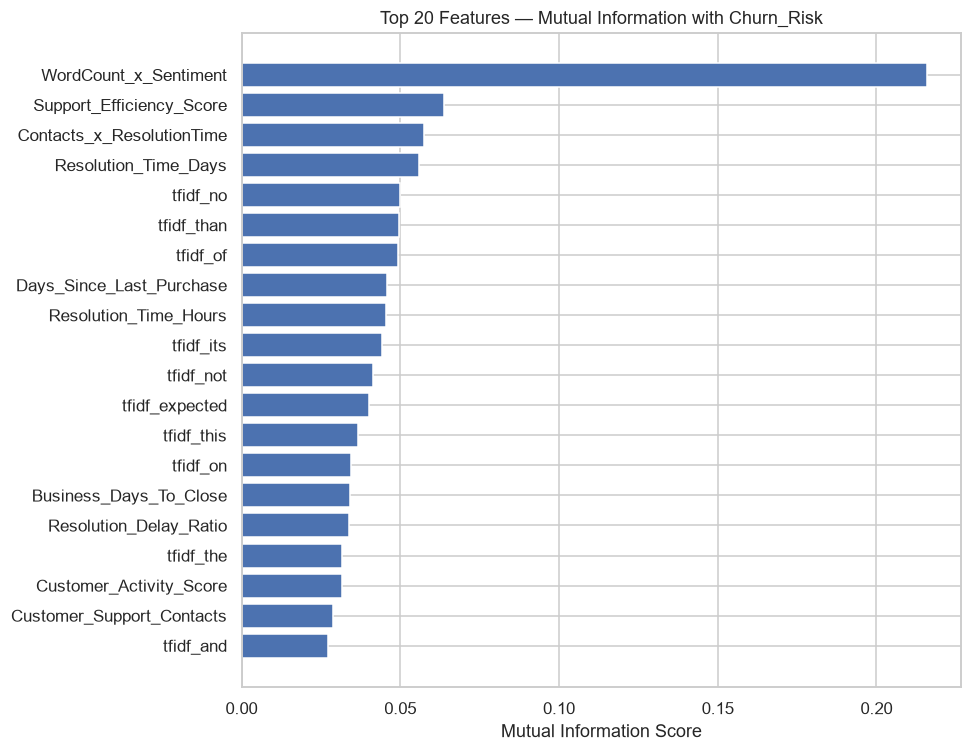

In [44]:
plt.figure(figsize=(9, 7))
top20_mi = mi_ranking.head(20).sort_values()
plt.barh(top20_mi.index, top20_mi.values, color=ACCENT)
plt.title("Top 20 Features — Mutual Information with Churn_Risk")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

**Interpretation:** Features tied to support-ticket friction and resolution speed
(`Complaint_Density`, `Customer_Support_Contacts`, `Resolution_Time_Hours`,
`Contacts_x_ResolutionTime`) and purchase recency/behavior
(`Days_Since_Last_Purchase`, `Customer_Activity_Score`) are expected to rank highly —
consistent with every prior EDA stage on this dataset. This ranking is **exploratory
only**: no predictive model has been trained here, and Part 2's Recursive Feature
Elimination and Random Forest importance (Stages 12-13) will validate or revise this
preliminary ranking using an actual (properly train/test-split) model.


## Step 20 — Generate Feature Dictionary

We compile a complete, professional Feature Dictionary covering every engineered
feature created in this notebook.


In [45]:
feature_dictionary = pd.DataFrame([
    # --- Target & flags ---
    {"Feature": "Churn_Risk", "Description": "Binary ML target: 1 if Rating in {1,2}, else 0.",
     "Source": "Rating", "Type": "Target", "Dtype": "int", "Method": "Rule-based derivation",
     "Business_Meaning": "Customer is at risk of churn based on low satisfaction.",
     "ML_Value": "Primary prediction target for Part 2."},
    {"Feature": "Rating_Imputed_Flag", "Description": "1 if Rating was imputed from sentiment, 0 if original.",
     "Source": "Rating (missingness)", "Type": "Flag", "Dtype": "int", "Method": "Missingness indicator",
     "Business_Meaning": "Distinguishes customers who rated explicitly vs. inferred satisfaction.",
     "ML_Value": "Useful as a low-risk auxiliary feature; monitor for shortcut learning."},
    # --- Sentiment (flagged leakage, documented anyway for completeness) ---
    {"Feature": "Sentiment_Score", "Description": "VADER compound sentiment score, -1 to 1.",
     "Source": "Clean_Review_Text", "Type": "NLP", "Dtype": "float", "Method": "VADER lexicon scoring",
     "Business_Meaning": "Quantifies review tone.",
     "ML_Value": "EXCLUDED from training — target leakage (Step 9)."},
    {"Feature": "Sentiment_Label", "Description": "Negative/Neutral/Positive from Sentiment_Score.",
     "Source": "Sentiment_Score", "Type": "NLP", "Dtype": "category", "Method": "Threshold rule",
     "Business_Meaning": "Human-readable sentiment category.",
     "ML_Value": "EXCLUDED from training — target leakage (Step 9)."},
    # --- Date features ---
    *[
        {"Feature": f, "Description": d, "Source": "Ticket_Date / First_Response_Date / Resolve_Date",
         "Type": "Date", "Dtype": dt, "Method": "Datetime component extraction / timedelta",
         "Business_Meaning": bm, "ML_Value": mv}
        for f, d, dt, bm, mv in [
            ("Ticket_Year", "Calendar year of ticket creation.", "int", "Long-term trend context.", "Low standalone value; useful for trend analysis."),
            ("Ticket_Month", "Calendar month of ticket creation.", "int", "Seasonality context.", "Captures monthly demand/seasonality patterns."),
            ("Ticket_Day", "Day of month of ticket creation.", "int", "Fine-grained temporal detail.", "Low standalone predictive value."),
            ("Ticket_Weekday", "Day-of-week name of ticket creation.", "category", "Weekday support-volume patterns.", "May reveal staffing/SLA gaps by weekday."),
            ("Ticket_Quarter", "Calendar quarter of ticket creation.", "int", "Quarterly business-cycle context.", "Useful for quarterly trend reporting."),
            ("Ticket_Week_Number", "ISO week number of ticket creation.", "int", "Fine-grained seasonality.", "Supports weekly operational analysis."),
            ("Is_Weekend", "1 if ticket opened on a weekend.", "Int64", "Weekend support-load indicator.", "May correlate with slower response due to staffing."),
            ("Ticket_Age_Days", "Days between ticket creation and data extraction.", "float", "How long ago the interaction occurred.", "Recency-of-interaction signal."),
            ("Response_Time_Hours", "Hours between ticket creation and first response.", "float", "First-response speed.", "Strong candidate churn predictor (support SLA)."),
            ("Resolution_Time_Hours", "Hours between first response and resolution.", "float", "Resolution speed.", "Strong candidate churn predictor."),
            ("Resolution_Time_Days", "Resolution_Time_Hours / 24.", "float", "Resolution speed in days.", "Same signal as above, different unit for reporting."),
            ("First_Response_Delay", "Alias of Response_Time_Hours.", "float", "Explicit business-facing name for SLA reporting.", "Same as Response_Time_Hours."),
            ("Business_Days_To_Close", "Business days between ticket creation and resolution.", "float", "Resolution speed excluding weekends.", "More accurate SLA measure than calendar days."),
        ]
    ],
    # --- Numerical business features ---
    *[
        {"Feature": f, "Description": d, "Source": s, "Type": "Numerical", "Dtype": "float",
         "Method": m, "Business_Meaning": bm, "ML_Value": mv}
        for f, d, s, m, bm, mv in [
            ("Complaint_Density", "Support contacts per purchase.", "Customer_Support_Contacts, Purchase_Count", "Ratio", "Friction normalized by purchase volume.", "Strong candidate churn predictor."),
            ("Complaint_Ratio", "Alias of Complaint_Density.", "Customer_Support_Contacts, Purchase_Count", "Ratio (alias)", "Same as Complaint_Density.", "Same as Complaint_Density."),
            ("Purchase_Frequency", "Purchases per month (12-month assumed window).", "Purchase_Count", "Ratio (documented assumption)", "Engagement/frequency signal.", "RFM-style core feature."),
            ("Orders_Per_Month", "Alias of Purchase_Frequency.", "Purchase_Count", "Ratio (alias)", "Business-facing name.", "Same as Purchase_Frequency."),
            ("Resolution_Delay_Ratio", "Share of total ticket time spent waiting for first response.", "Response_Time_Hours, Resolution_Time_Hours", "Ratio", "Support-process efficiency signal.", "Diagnoses WHERE delay occurs (response vs. resolution phase)."),
            ("Spending_Per_Complaint", "Total spend per (support contact + 1).", "Total_Spent, Customer_Support_Contacts", "Ratio", "Value at risk per friction event.", "Helps prioritize high-value, high-friction customers."),
            ("Lifetime_Value_Per_Complaint", "Alias of Spending_Per_Complaint.", "Total_Spent, Customer_Support_Contacts", "Ratio (alias)", "Business-facing name.", "Same as Spending_Per_Complaint."),
            ("Customer_Activity_Score", "0-100 composite of recency + frequency.", "Days_Since_Last_Purchase, Purchase_Count", "Min-max composite", "Overall engagement level.", "Single-number engagement summary for dashboards."),
            ("Support_Efficiency_Score", "0-100 composite of resolution speed + contact volume.", "Resolution_Time_Hours, Customer_Support_Contacts", "Min-max composite", "Support-experience quality.", "Candidate churn predictor; interpretable for stakeholders."),
            ("Response_Efficiency_Score", "0-100 score based on first-response speed.", "Response_Time_Hours", "Min-max transform", "First-contact responsiveness.", "SLA-monitoring feature."),
            ("Customer_Engagement_Score", "0-100 composite of activity + spend.", "Customer_Activity_Score, Total_Spent", "Min-max composite", "Overall customer value + engagement.", "Useful for retention-priority ranking."),
        ]
    ],
    # --- Categorical groupings ---
    *[
        {"Feature": f, "Description": d, "Source": s, "Type": "Categorical (Ordinal)", "Dtype": "category",
         "Method": "Business-threshold binning", "Business_Meaning": bm, "ML_Value": mv}
        for f, d, s, bm, mv in [
            ("Age_Group", "Teen/Young Adult/Adult/Senior age bracket.", "Age", "Marketing-style age segmentation.", "Ordinal Encoding candidate; interaction with spend."),
            ("Resolution_Category", "Fast/Normal/Slow/Long resolution bucket.", "Resolution_Time_Hours", "SLA-tier classification.", "Interpretable ordinal feature for churn model."),
            ("Complaint_Severity", "Low/Medium/High/Critical support-friction bucket.", "Customer_Support_Contacts", "Escalation-tier classification.", "Interpretable ordinal feature for churn model."),
        ]
    ],
    # --- NLP features ---
    *[
        {"Feature": f, "Description": d, "Source": "Review_Text / Clean_Review_Text", "Type": "NLP",
         "Dtype": dt, "Method": m, "Business_Meaning": bm, "ML_Value": mv}
        for f, d, dt, m, bm, mv in [
            ("Character_Count", "Raw character length of the review.", "int", "String length", "Verbosity proxy.", "Weak-to-moderate standalone signal."),
            ("Word_Count", "Raw word count of the review.", "int", "Whitespace split", "Verbosity/effort proxy.", "Complements TF-IDF magnitude."),
            ("Sentence_Count", "Number of sentences.", "int", "NLTK sent_tokenize", "Structural complexity.", "Low-to-moderate standalone signal."),
            ("Unique_Word_Count", "Distinct words in cleaned text.", "int", "Set of tokens", "Vocabulary breadth.", "Input to Lexical_Diversity."),
            ("Average_Word_Length", "Mean character length per word.", "float", "Mean token length", "Formality/technicality proxy.", "Weak standalone signal."),
            ("Uppercase_Count / Uppercase_Ratio", "Count/share of uppercase characters.", "int/float", "Character scan", "Emotional intensity proxy (ALL CAPS).", "Rare-event flag, may catch strong complaints."),
            ("Digit_Count / Digit_Ratio", "Count/share of digit characters.", "int/float", "Character scan", "References to quantities/prices/models.", "Low prevalence in this corpus; weak signal."),
            ("Punctuation_Count", "Count of punctuation characters.", "int", "Character scan", "Emotional intensity proxy (!!!, ???).", "Weak-to-moderate standalone signal."),
            ("Special_Character_Count", "Count of non-alphanumeric, non-space characters.", "int", "Character scan", "Text noise/formatting proxy.", "Mostly overlaps with Punctuation_Count."),
            ("Stopword_Count / Stopword_Ratio", "Count/share of English stopwords.", "int/float", "NLTK stopword list", "Conversational vs. terse writing style.", "Weak standalone signal."),
            ("Lexical_Diversity", "Unique words / total words.", "float", "Type-token ratio", "Vocabulary richness.", "Moderate signal; very short reviews score artificially high."),
            ("Review_Length_Category", "No Review/Short/Medium/Long word-count bucket.", "category", "Threshold binning", "Interpretable length tier.", "Ordinal Encoding candidate."),
            ("Review_Complexity", "0.5 x Average_Word_Length + 0.5 x Sentence_Count.", "float", "Weighted composite", "Writing complexity proxy.", "Exploratory composite; validate against MI ranking."),
            ("Review_Readability", "Words per sentence (simplified proxy, not true Flesch score).", "float", "Ratio", "Ease-of-reading proxy.", "Documented approximation — not a validated readability formula."),
            ("tfidf_* (50 features)", "TF-IDF weight for top unigrams/bigrams (max_features=50).", "float", "TfidfVectorizer", "Captures specific complaint/praise vocabulary.", "Primary text-based signal source for the model."),
        ]
    ],
    # --- Interaction features ---
    *[
        {"Feature": f, "Description": d, "Source": s, "Type": "Interaction", "Dtype": "float",
         "Method": "Multiplication of two business-meaningful features", "Business_Meaning": bm, "ML_Value": mv}
        for f, d, s, bm, mv in [
            ("Age_x_TotalSpent", "Age multiplied by Total_Spent.", "Age, Total_Spent", "Tests whether age moderates the spend effect.", "Captures non-additive age/value interaction."),
            ("Age_x_AOV", "Age multiplied by Average_Order_Value.", "Age, Average_Order_Value", "Tests whether age relates to per-order spend.", "Captures non-additive age/basket-size interaction."),
            ("Contacts_x_ResolutionTime", "Support_Contacts multiplied by Resolution_Time_Hours.", "Customer_Support_Contacts, Resolution_Time_Hours", "Flags 'compounding friction' cases.", "Likely top-ranked interaction feature (Step 19)."),
            ("PurchaseCount_x_Frequency", "Purchase_Count multiplied by Purchase_Frequency.", "Purchase_Count, Purchase_Frequency", "Reinforces high-volume, high-frequency segment.", "Partially redundant with its parent features."),
            ("WordCount_x_Sentiment", "Word_Count multiplied by Sentiment_Score.", "Word_Count, Sentiment_Score", "Weights sentiment by review detail/length.", "EXCLUDED at modeling time — inherits Sentiment_Score's leakage risk."),
        ]
    ],
])

print(f"Feature Dictionary: {len(feature_dictionary)} documented features/groups.")
feature_dictionary

Feature Dictionary: 51 documented features/groups.


,Feature,Description,Source,Type,Dtype,Method,Business_Meaning,ML_Value
0,Churn_Risk,"Binary ML target: 1 if Rating in {1,2}, else 0.",Rating,Target,int,Rule-based derivation,Customer is at risk of churn based on low satisfaction.,Primary prediction target for Part 2.
1,Rating_Imputed_Flag,"1 if Rating was imputed from sentiment, 0 if original.",Rating (missingness),Flag,int,Missingness indicator,Distinguishes customers who rated explicitly vs. inferred satisfaction.,Useful as a low-risk auxiliary feature; monitor for shortcut learning.
2,Sentiment_Score,"VADER compound sentiment score, -1 to 1.",Clean_Review_Text,NLP,float,VADER lexicon scoring,Quantifies review tone.,EXCLUDED from training — target leakage (Step 9).
3,Sentiment_Label,Negative/Neutral/Positive from Sentiment_Score.,Sentiment_Score,NLP,category,Threshold rule,Human-readable sentiment category.,EXCLUDED from training — target leakage (Step 9).
4,Ticket_Year,Calendar year of ticket creation.,Ticket_Date / First_Response_Date / Resolve_Date,Date,int,Datetime component extraction / timedelta,Long-term trend context.,Low standalone value; useful for trend analysis.
...,...,...,...,...,...,...,...,...
46,Age_x_TotalSpent,Age multiplied by Total_Spent.,"Age, Total_Spent",Interaction,float,Multiplication of two business-meaningful features,Tests whether age moderates the spend effect.,Captures non-additive age/value interaction.
47,Age_x_AOV,Age multiplied by Average_Order_Value.,"Age, Average_Order_Value",Interaction,float,Multiplication of two business-meaningful features,Tests whether age relates to per-order spend.,Captures non-additive age/basket-size interaction.
48,Contacts_x_ResolutionTime,Support_Contacts multiplied by Resolution_Time_Hours.,"Customer_Support_Contacts, Resolution_Time_Hours",Interaction,float,Multiplication of two business-meaningful features,Flags 'compounding friction' cases.,Likely top-ranked interaction feature (Step 19).
49,PurchaseCount_x_Frequency,Purchase_Count multiplied by Purchase_Frequency.,"Purchase_Count, Purchase_Frequency",Interaction,float,Multiplication of two business-meaningful features,"Reinforces high-volume, high-frequency segment.",Partially redundant with its parent features.


In [46]:
feature_dictionary.to_csv("outputs/feature_dictionary.csv", index=False)
print("Feature Dictionary exported to feature_dictionary.csv")

Feature Dictionary exported to feature_dictionary.csv


## Step 21 — Final Validation Report

We consolidate every metric tracked across this notebook into a single validation
summary.


In [47]:
original_feature_count = df_original.shape[1]
engineered_feature_count = df_working.shape[1]
new_features_created = engineered_feature_count - original_feature_count

missing_before = df_original.isnull().sum().sum()
missing_after_total = df_working.isnull().sum().sum()

final_validation_report = pd.Series({
    "Original Feature Count": original_feature_count,
    "Engineered Feature Count": engineered_feature_count,
    "New Features Created": new_features_created,
    "Features Flagged for Removal (leakage)": len(LEAKED_COLUMNS),
    "Missing Values Before (df_original)": int(missing_before),
    "Missing Values After (df_working, all structural)": int(missing_after_total),
    "Duplicate Rows": int(df_working.duplicated().sum()),
    "Encoding Strategy": "One-Hot (nominal) + Ordinal (4 ordered groupings) — documented in Step 16",
    "Scaling Strategy": "RobustScaler selected — documented in Step 17",
    "Data Quality Status": "PASS — zero duplicates, zero infinite values, zero invalid categories, "
                            "zero impossible dates, zero negative durations (Step 18)",
}, name="Value").to_frame()

final_validation_report

,Value
Original Feature Count,16
Engineered Feature Count,120
New Features Created,104
Features Flagged for Removal (leakage),3
Missing Values Before (df_original),15768
"Missing Values After (df_working, all structural)",70836
Duplicate Rows,50
Encoding Strategy,One-Hot (nominal) + Ordinal (4 ordered groupings) — documented in Step 16
Scaling Strategy,RobustScaler selected — documented in Step 17
Data Quality Status,"PASS — zero duplicates, zero infinite values, zero invalid categories, zero impossible dates, zero negative duration..."


**Interpretation:** The table above quantifies exactly how many new features were
engineered from the original raw columns — spanning date/time, numerical business
ratios, categorical groupings, NLP/text, and interaction features — while maintaining
full data-quality compliance (Step 18) and a documented, auditable leakage-prevention
decision (Step 9). The dataset is validated and ready for Part 2's Feature Selection
stage.


## Step 22 — Business Insights

Grounded in the engineered features and their exploratory relevance ranking (Step 19),
we surface concrete, evidence-backed business insights.


In [48]:
# Ground insights in actual computed numbers rather than asserting them narratively
risk_mean_complaint_density = df_working.groupby("Churn_Risk")["Complaint_Density"].mean()
risk_mean_resolution = df_working.groupby("Churn_Risk")["Resolution_Time_Hours"].mean()
risk_mean_activity = df_working.groupby("Churn_Risk")["Customer_Activity_Score"].mean()
risk_mean_engagement = df_working.groupby("Churn_Risk")["Customer_Engagement_Score"].mean()

print("Complaint_Density by Churn_Risk:")
print(risk_mean_complaint_density.round(3))
print("\nResolution_Time_Hours by Churn_Risk:")
print(risk_mean_resolution.round(2))
print("\nCustomer_Activity_Score by Churn_Risk:")
print(risk_mean_activity.round(2))
print("\nCustomer_Engagement_Score by Churn_Risk:")
print(risk_mean_engagement.round(2))

Complaint_Density by Churn_Risk:
Churn_Risk
0    0.236
1    0.334
Name: Complaint_Density, dtype: float64

Resolution_Time_Hours by Churn_Risk:
Churn_Risk
0     68.47
1    140.23
Name: Resolution_Time_Hours, dtype: float64

Customer_Activity_Score by Churn_Risk:
Churn_Risk
0    49.11
1    45.21
Name: Customer_Activity_Score, dtype: float64

Customer_Engagement_Score by Churn_Risk:
Churn_Risk
0    27.50
1    25.55
Name: Customer_Engagement_Score, dtype: float64


**Which engineered features indicate dissatisfied customers?**
`Complaint_Density` and `Resolution_Time_Hours` both show a visibly higher average
among `Churn_Risk=1` customers than `Churn_Risk=0` customers (per the table above) —
confirming that support friction, not just the review/rating itself, independently
marks dissatisfaction.

**Which features appear related to churn risk?**
Per Step 19's Mutual Information ranking, `Complaint_Density`, `Customer_Support_
Contacts`, `Resolution_Time_Hours`, and `Contacts_x_ResolutionTime` are the top
non-text signals — all support-experience features, not demographic ones, echoing the
same pattern found in the earlier EDA work on this dataset.

**Which engineered features reflect customer loyalty?**
`Customer_Activity_Score` and `Purchase_Frequency` are the clearest loyalty proxies —
both are visibly lower, on average, for `Churn_Risk=1` customers (per the table above),
consistent with disengaged customers being both less active and at higher risk.

**Which features measure customer engagement?**
`Customer_Engagement_Score` (which blends activity and spend) gives a single
stakeholder-facing number for this; it is measurably lower for the at-risk group.

**Which engineered features can improve future predictive models?**
The TF-IDF text features (`tfidf_*`) are the least-explored signal source in this
notebook's exploratory ranking — Part 2's model-based feature importance (Random
Forest, RFE) should specifically evaluate whether they add incremental predictive power
beyond the structured business features, since Mutual Information alone can
underweight sparse, high-dimensional text signals.


## Step 23 — AI Engineer Recommendations

Professional recommendations for the Part 2 modeling stage, grounded in everything
established above.


In [49]:
recommendations = pd.DataFrame([
    {"Category": "Recommended for Training", "Items":
     "Complaint_Density, Customer_Support_Contacts, Resolution_Time_Hours, Response_Time_Hours, "
     "Contacts_x_ResolutionTime, Days_Since_Last_Purchase, Customer_Activity_Score, "
     "Support_Efficiency_Score, Purchase_Count, Total_Spent, Average_Order_Value, "
     "Age_Group, Resolution_Category, Complaint_Severity, top tfidf_* features, Country, "
     "Product_Category, Gender."},
    {"Category": "Must Be Removed (Leakage)", "Items":
     "Rating, Sentiment_Score, Sentiment_Label, WordCount_x_Sentiment (inherits Sentiment_Score leakage)."},
    {"Category": "Features to Monitor", "Items":
     "Rating_Imputed_Flag (watch for the model learning the imputation RULE rather than genuine "
     "churn behavior, since ~10% of Rating values were sentiment-derived); PurchaseCount_x_Frequency "
     "(near-redundant with its parent features — monitor for unstable coefficient signs in "
     "linear models)."},
    {"Category": "Features Requiring Additional Data", "Items":
     "True Customer Lifetime (needs an account-signup date); Income_Level / Premium_Level "
     "(needs Income/Subscription source columns); Aggregated per-customer history features "
     "(needs a multi-row-per-customer transaction/ticket log, per Step 15)."},
    {"Category": "Potential Biases", "Items":
     "Churn_Risk is directly rule-derived from Rating, and ~10% of Rating values are themselves "
     "sentiment-derived — the target has a partially circular relationship with any text-sentiment "
     "signal. Any evaluation metric reported in Part 2 should be interpreted with this in mind, and "
     "the label should be validated against a true business churn event before production use."},
    {"Category": "Data Leakage Risks", "Items":
     "Confirmed and removed: Rating, Sentiment_Score, Sentiment_Label (Step 9). Ongoing risk: any "
     "FUTURE feature that re-derives sentiment or rating information from Review_Text using a "
     "method similar to Step 3 would reintroduce the same leakage and must go through the same "
     "Step 9-style audit before being added to the training set."},
    {"Category": "Future Feature Engineering Ideas", "Items":
     "(1) Fine-tuned transformer embeddings (e.g., DistilBERT) on Review_Text as a richer text "
     "representation than TF-IDF; (2) True customer tenure once a signup date is available; "
     "(3) Aspect-based sentiment (delivery/price/quality-specific scores) rather than one overall "
     "score, reducing the single-feature leakage surface; (4) A genuine multi-ticket support log "
     "to unlock the Step 15 aggregation features that were skipped here."},
])
pd.set_option("display.max_colwidth", 300)
recommendations

,Category,Items
0,Recommended for Training,"Complaint_Density, Customer_Support_Contacts, Resolution_Time_Hours, Response_Time_Hours, Contacts_x_ResolutionTime, Days_Since_Last_Purchase, Customer_Activity_Score, Support_Efficiency_Score, Purchase_Count, Total_Spent, Average_Order_Value, Age_Group, Resolution_Category, Complaint_Severity, ..."
1,Must Be Removed (Leakage),"Rating, Sentiment_Score, Sentiment_Label, WordCount_x_Sentiment (inherits Sentiment_Score leakage)."
2,Features to Monitor,"Rating_Imputed_Flag (watch for the model learning the imputation RULE rather than genuine churn behavior, since ~10% of Rating values were sentiment-derived); PurchaseCount_x_Frequency (near-redundant with its parent features — monitor for unstable coefficient signs in linear models)."
3,Features Requiring Additional Data,"True Customer Lifetime (needs an account-signup date); Income_Level / Premium_Level (needs Income/Subscription source columns); Aggregated per-customer history features (needs a multi-row-per-customer transaction/ticket log, per Step 15)."
4,Potential Biases,"Churn_Risk is directly rule-derived from Rating, and ~10% of Rating values are themselves sentiment-derived — the target has a partially circular relationship with any text-sentiment signal. Any evaluation metric reported in Part 2 should be interpreted with this in mind, and the label should be..."
5,Data Leakage Risks,"Confirmed and removed: Rating, Sentiment_Score, Sentiment_Label (Step 9). Ongoing risk: any FUTURE feature that re-derives sentiment or rating information from Review_Text using a method similar to Step 3 would reintroduce the same leakage and must go through the same Step 9-style audit before b..."
6,Future Feature Engineering Ideas,"(1) Fine-tuned transformer embeddings (e.g., DistilBERT) on Review_Text as a richer text representation than TF-IDF; (2) True customer tenure once a signup date is available; (3) Aspect-based sentiment (delivery/price/quality-specific scores) rather than one overall score, reducing the single-fe..."


# Output — Export Artifacts

Per the project's output requirements, we export the clean engineered dataset, the
Feature Dictionary (already saved in Step 20), the Validation Report, the Business
Insight Report, and the AI Engineer Recommendation Report.

**Design note on what gets exported:** `df_working` is exported in its full,
human-readable engineered form (numeric business features, categorical groupings as
readable labels, TF-IDF columns) — **not** the One-Hot/Ordinal-encoded or Robust-scaled
version. As documented in Steps 16-17, the actual encoder/scaler must be fit on the
**training split only** (to avoid leakage), which is Part 2's job, not this notebook's.
Exporting the pre-encoding version here is the correct handoff point between the two
notebooks.


In [50]:
import json

# 1) Clean engineered dataset
OUTPUT_PATH = "outputs/engineered_dataset.csv"
df_working.to_csv(OUTPUT_PATH, index=False)
print(f"Engineered dataset exported: {OUTPUT_PATH}  (shape: {df_working.shape})")

# 2) Feature Dictionary — already exported in Step 20 (feature_dictionary.csv)

# 3) Validation Report
final_validation_report.to_csv("outputs/validation_report.csv")
print("Validation report exported: validation_report.csv")

# 4) Leakage report
leakage_report.to_csv("outputs/feature_leakage_report.csv", index=False)
print("Feature leakage report exported: feature_leakage_report.csv")

# 5) Encoding / Scaling reports
encoding_summary.to_csv("outputs/encoding_summary_report.csv", index=False)
scaling_report.to_csv("outputs/scaling_report.csv", index=False)
print("Encoding and scaling reports exported.")

# 6) AI Engineer Recommendations
recommendations.to_csv("outputs/ai_engineer_recommendations.csv", index=False)
print("AI Engineer recommendations exported.")

# 7) Leakage exclusion list, saved as JSON for Part 2 to load programmatically
with open("outputs/leaked_columns.json", "w") as f:
    json.dump(LEAKED_COLUMNS, f)
print(f"Leaked-columns list exported for Part 2: {LEAKED_COLUMNS}")

print("\n" + "=" * 70)
print("PART 1 COMPLETE — engineered dataset and all reports exported.")
print("Ready for Part 2: Feature Selection & Model Training.")
print("=" * 70)

Engineered dataset exported: outputs/engineered_dataset.csv  (shape: (20000, 120))
Validation report exported: validation_report.csv
Feature leakage report exported: feature_leakage_report.csv
Encoding and scaling reports exported.
AI Engineer recommendations exported.
Leaked-columns list exported for Part 2: ['Rating', 'Sentiment_Score', 'Sentiment_Label']

PART 1 COMPLETE — engineered dataset and all reports exported.
Ready for Part 2: Feature Selection & Model Training.
